In [1]:
# Common Libraries
import pandas as pd
import numpy as np
import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict

import scipy.stats as stats

In [2]:
# Additional Libraries
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import PowerTransformer
from scipy.stats import boxcox, boxcox_normmax
from scipy.special import inv_boxcox

In [3]:
# Import common help function
from helpers.common_help_functions import log_likelihood
from helpers.common_help_functions import percentile_bin_feature

In [4]:
# Set working directory to root of git repository
import os
import subprocess
repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
os.chdir(repo_root)

---
### Prepare data

In [5]:
# Import data
utmb_results_years = [2022, 2023, 2024, 2025]

data_path = Path("data")
utmb_race_results_runner_statistics_path = data_path / "utmb_race_results_runner_statistics"

# Year by year Combined Race Results and Runner Statistics data
race_results_runner_statistics_data_dict = {
    year: pd.read_csv(utmb_race_results_runner_statistics_path / f"utmb_{year}_race_results_runner_statistics.csv")
    for year in utmb_results_years
}

# All years Combined Race Results and Runner Statistics data
race_results_runner_statistics_data = pd.read_csv(utmb_race_results_runner_statistics_path / f"utmb_race_results_runner_statistics.csv", low_memory=False)

In [6]:
# Clean data

# Runner final status:
# - hd --> Out of time on some of the checkpoints [Finisher = False]
# - a --> Abandoned (withdrew voluntarily) [Finisher = False]
# - s --> Did not finish? [Finisher = False]
# - f --> Finisher [Finisher = True]
display(race_results_runner_statistics_data[["runner_final_status", "runner_is_finisher"]].value_counts(normalize=True).reset_index())
race_results_runner_statistics_finished_data = race_results_runner_statistics_data.query("runner_is_finisher == @True").reset_index(drop=True).copy()

,runner_final_status,runner_is_finisher,proportion
0,f,True,0.659945
1,a,False,0.301335
2,hd,False,0.038625
3,s,False,0.000095


In [7]:
# About
for year in race_results_runner_statistics_data["race_year"].unique():
    data_tmp = race_results_runner_statistics_data.query("race_year == @year").reset_index(drop=True).copy()
    data_finisher_tmp = race_results_runner_statistics_finished_data.query("race_year == @year").reset_index(drop=True).copy()
    print(f"\nYear: {year}")
    print("---------------------------------------")
    print("Number of starters = {:,}".format(len(data_tmp)))
    print("Proportion of finishers = {:.1%}".format(data_tmp["runner_is_finisher"].mean()))
    print("Finish time: mean = {:.2f}h, std = {:.2f}h, q25 = {:.2f}h, q75 = {:.2f}h".format(
        data_finisher_tmp["runner_race_time_hours"].mean(),
        data_finisher_tmp["runner_race_time_hours"].std(),
        data_finisher_tmp["runner_race_time_hours"].quantile(0.25),
        data_finisher_tmp["runner_race_time_hours"].quantile(0.75),
    ))
    print("Fastest finish time = {:.2f}h, Slowest finish time = {:.2f}h".format(
        data_finisher_tmp["runner_race_time_hours"].min(),
        data_finisher_tmp["runner_race_time_hours"].max(),
    ))



Year: 2022
---------------------------------------
Number of starters = 2,627
Proportion of finishers = 68.1%
Finish time: mean = 39.03h, std = 5.77h, q25 = 35.38h, q75 = 43.97h
Fastest finish time = 19.82h, Slowest finish time = 47.20h

Year: 2023
---------------------------------------
Number of starters = 2,687
Proportion of finishers = 65.4%
Finish time: mean = 39.04h, std = 5.88h, q25 = 35.38h, q75 = 43.89h
Fastest finish time = 19.63h, Slowest finish time = 48.27h

Year: 2024
---------------------------------------
Number of starters = 2,760
Proportion of finishers = 63.8%
Finish time: mean = 39.03h, std = 6.00h, q25 = 35.37h, q75 = 44.01h
Fastest finish time = 19.91h, Slowest finish time = 46.76h

Year: 2025
---------------------------------------
Number of starters = 2,489
Proportion of finishers = 66.9%
Finish time: mean = 39.37h, std = 6.18h, q25 = 35.65h, q75 = 44.61h
Fastest finish time = 19.32h, Slowest finish time = 47.08h


In [8]:
# Train & Test data split ~> Train data = {2022, 2023, 2024}, Test data = {2025}

race_results_runner_statistics_train = race_results_runner_statistics_data.query("race_year < 2025").reset_index(drop=True).copy()
race_results_runner_statistics_finished_train =  race_results_runner_statistics_finished_data.query("race_year < 2025").reset_index(drop=True).copy()

race_results_runner_statistics_test = race_results_runner_statistics_data.query("race_year >= 2025").reset_index(drop=True).copy()
race_results_runner_statistics_finished_test = race_results_runner_statistics_finished_data.query("race_year >= 2025").reset_index(drop=True).copy()

Prepare dummies

In [9]:
# Gender
race_results_runner_statistics_finished_train["runner_gender_male"] = np.where(race_results_runner_statistics_finished_train["runner_gender"] == "H", 1, 0)
race_results_runner_statistics_finished_test["runner_gender_male"] = np.where(race_results_runner_statistics_finished_test["runner_gender"] == "H", 1, 0)

race_results_runner_statistics_train["runner_gender_male"] = np.where(race_results_runner_statistics_train["runner_gender"] == "H", 1, 0)
race_results_runner_statistics_test["runner_gender_male"] = np.where(race_results_runner_statistics_test["runner_gender"] == "H", 1, 0)

---
### Analysis

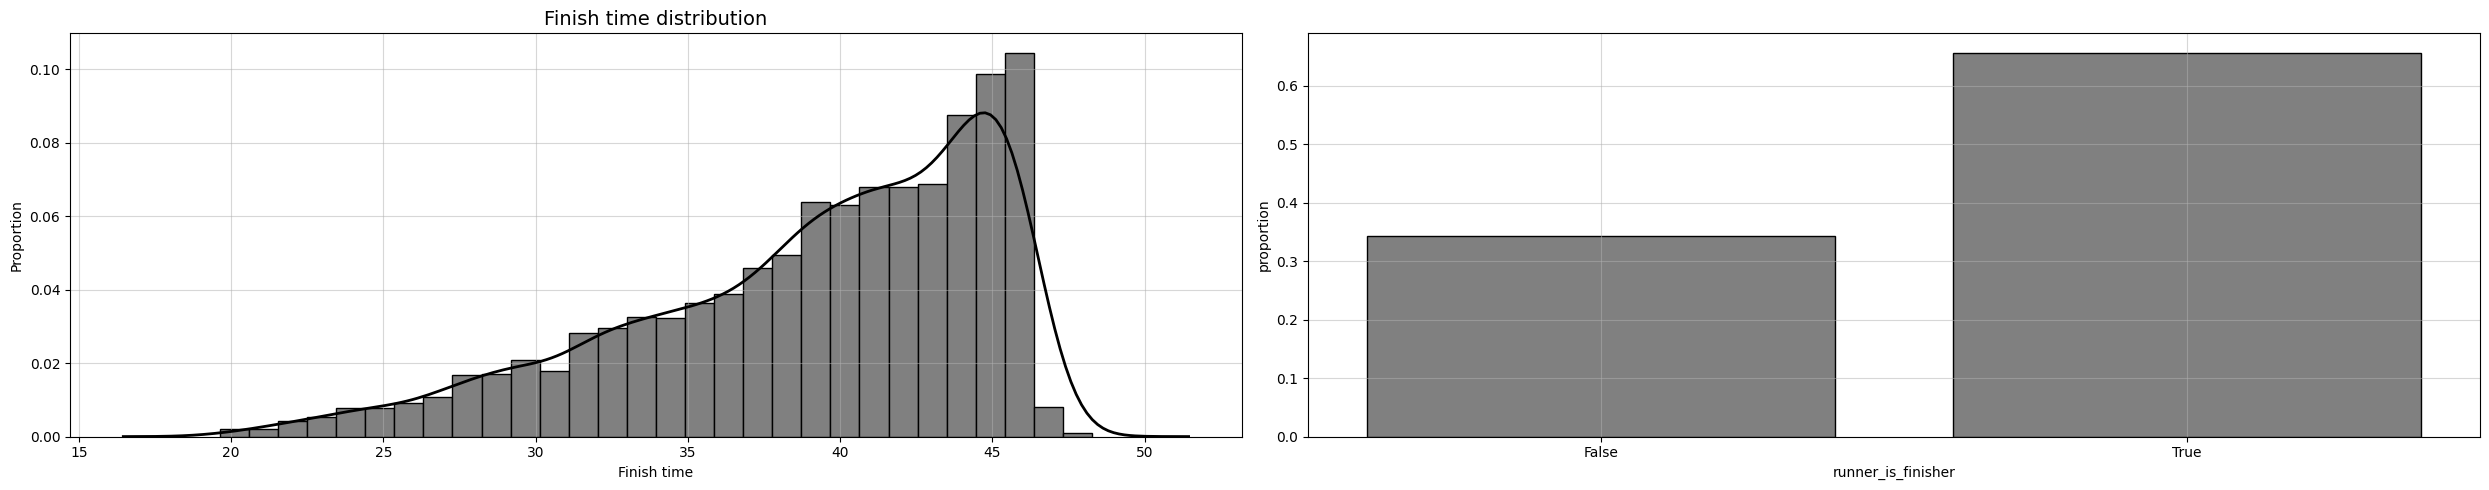

In [10]:
# Finish time distribution & DNF proportion distribution
fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution", fontsize=14)
ax[0].hist(race_results_runner_statistics_finished_train["runner_race_time_hours"], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(race_results_runner_statistics_finished_train["runner_race_time_hours"], ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

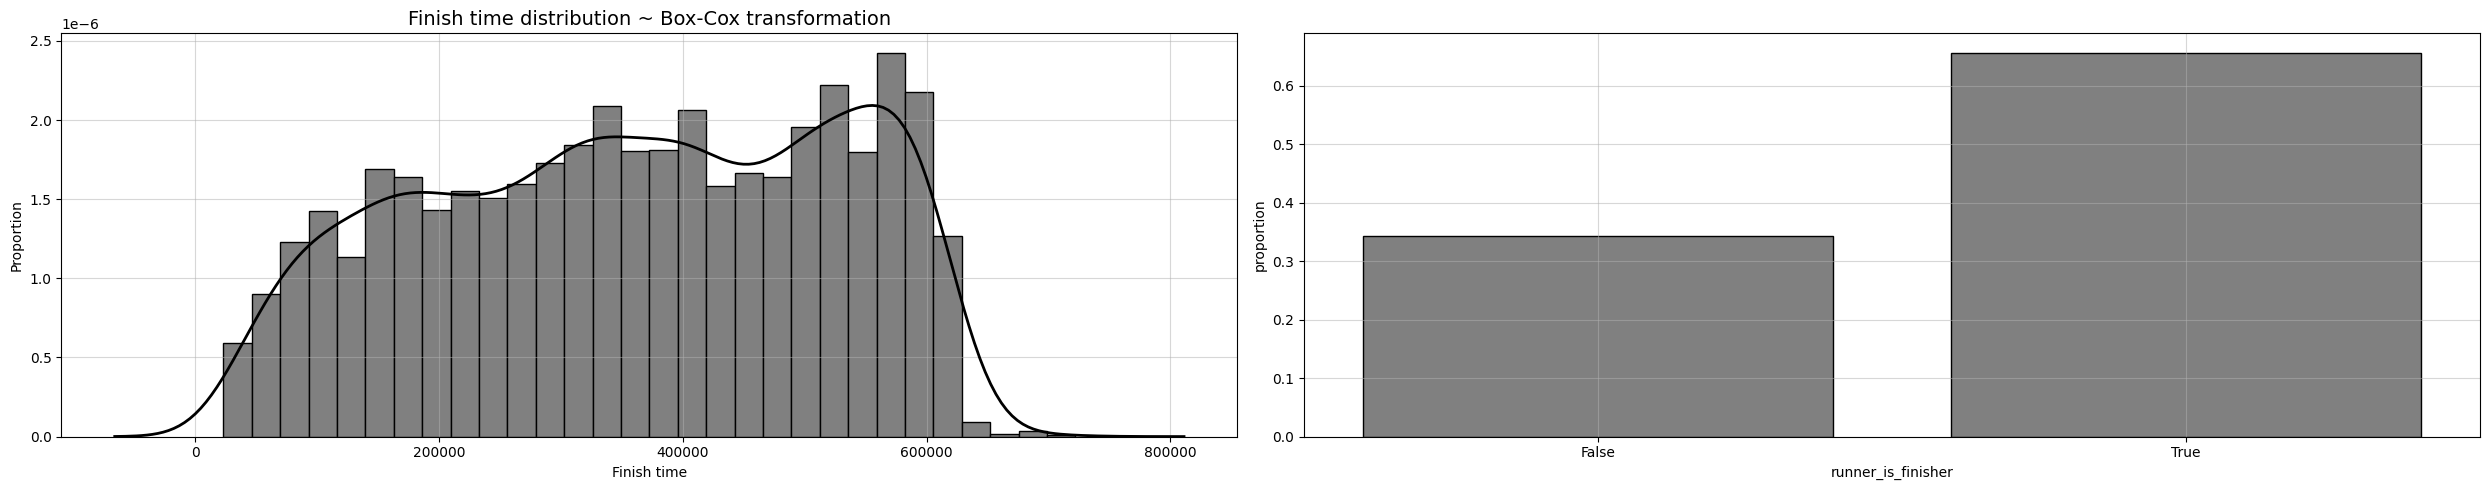

In [11]:
# Box-Cox Finish time distribution & DNF proportion distribution

target = race_results_runner_statistics_finished_train["runner_race_time_hours"]
lambda_bc = boxcox_normmax(target)
target_bc = boxcox(target, lmbda=lambda_bc)

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution ~ Box-Cox transformation", fontsize=14)
ax[0].hist(target_bc, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(target_bc, ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

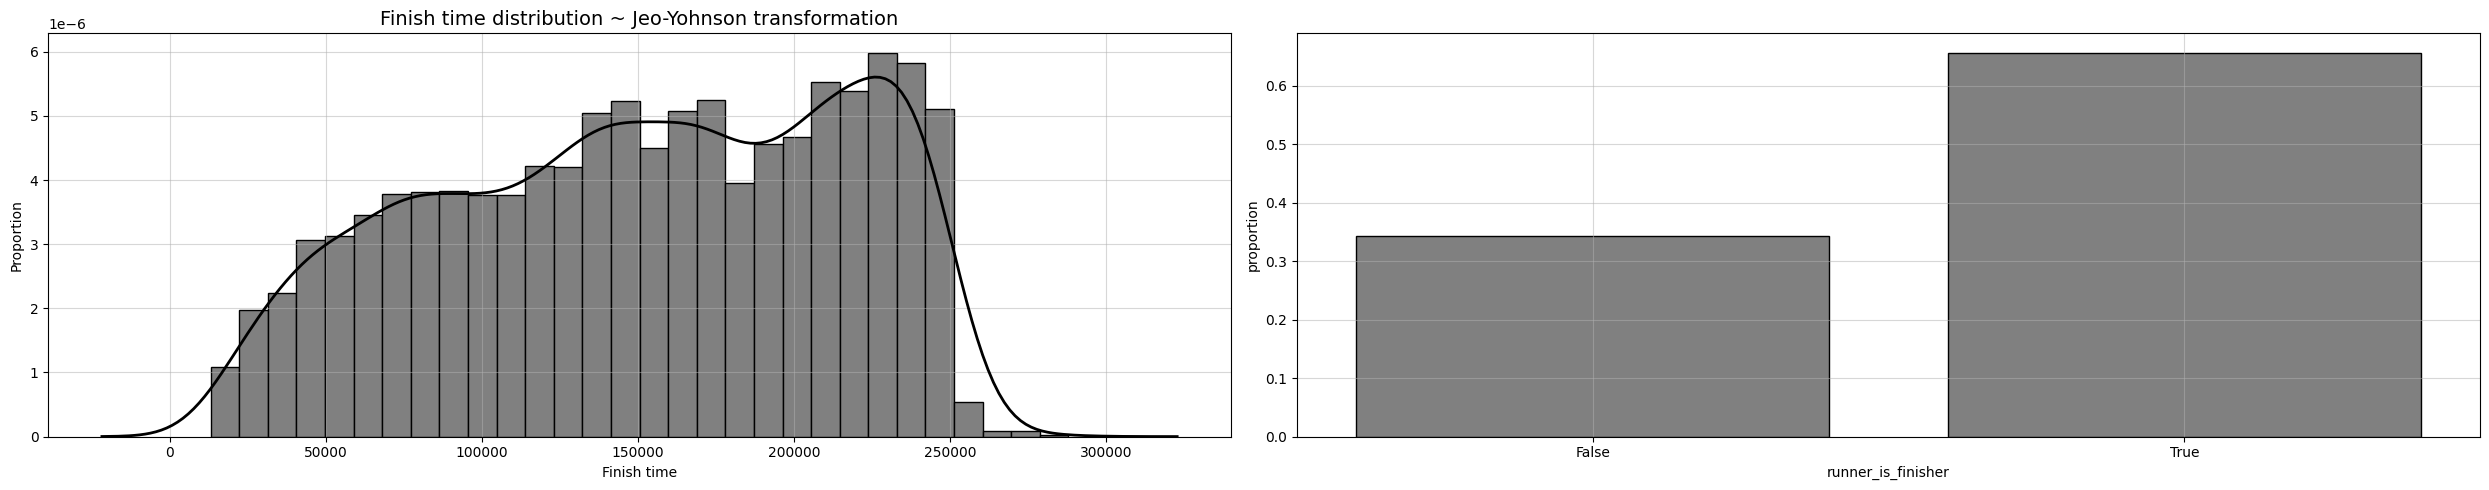

In [12]:
# Yeo-Johnson Finish time distribution & DNF proportion distribution
pt = PowerTransformer(method="yeo-johnson", standardize=False)
target = race_results_runner_statistics_finished_train["runner_race_time_hours"]
target_pt = pt.fit_transform(target.values.reshape(-1, 1)).flatten()

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution ~ Jeo-Yohnson transformation", fontsize=14)
ax[0].hist(target_pt, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(target_pt, ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

In [13]:
# Box-Cox transform finish times & Yeo-Johnson (PT) finish times

# Box-Cox
target_bc = race_results_runner_statistics_finished_train["runner_race_time_hours"]
lambda_bc = boxcox_normmax(target_bc)
race_results_runner_statistics_finished_train["runner_race_time_hours_bc"] = boxcox(target_bc, lmbda=lambda_bc)
race_results_runner_statistics_finished_train["runner_race_time_hours_inverse_bc"] = inv_boxcox(race_results_runner_statistics_finished_train["runner_race_time_hours_bc"], lambda_bc)

# Yeo-Johnson
pt = PowerTransformer(method="yeo-johnson", standardize=False)
target_pt =  race_results_runner_statistics_finished_train["runner_race_time_hours"]
race_results_runner_statistics_finished_train["runner_race_time_hours_pt"] = pt.fit_transform(target_pt.values.reshape(-1, 1)).flatten()
race_results_runner_statistics_finished_train["runner_race_time_hours_inverse_pt"] = pt.inverse_transform(race_results_runner_statistics_finished_train["runner_race_time_hours_pt"].values.reshape(-1, 1)).flatten()

---
### Race Finish Success ~ Univariate Logistic model

In [14]:
# Import help functions
from helpers.logistic_regression_help_functions import univariate_logit_numeric, univariate_logit_categorical

Quick run through "feature importances"

In [15]:
# Univariate analysis for all features and save metrics

# Features we want to perform univariate analysis on
features_to_analyse = [
    col for col in race_results_runner_statistics_train.columns if 
        "alltime" in col or 
        "last2years" in col or 
        col in ["runner_pre_race_index", "runner_gender", "runner_age"]
 ]

race_finisher_features_metrics_list = []
for single_feature in features_to_analyse:

    # Numeric features
    if pd.api.types.is_numeric_dtype(race_results_runner_statistics_train[single_feature]):
        try:
            single_feature_metrics = univariate_logit_numeric(
                target = "runner_is_finisher", target_name = "Finisher",
                feature = single_feature, feature_name = "Feature",
                data = race_results_runner_statistics_train,
                alpha = 0.1,
                print_metrics = False,
                show_plot = False
                )
        except:
            print("Problems for {}".format(single_feature))
    
    # Categorical features
    else:
        try:
            single_feature_metrics = univariate_logit_categorical(
                target = "runner_is_finisher", target_name = "Finisher",
                feature = single_feature, feature_name = "Feature",
                data = race_results_runner_statistics_train,
                alpha = 0.1,
                print_metrics = False,
                show_plot = False
                )
        except:
            print("Problems for {}".format(single_feature))

    # Save feature metrics DataFrame into a list
    race_finisher_features_metrics_list.append(single_feature_metrics)

# Combine all features metrics into a DataFrame
race_finisher_features_metrics_df = pd.concat(race_finisher_features_metrics_list, ignore_index=True)

In [16]:
# Check
race_finisher_features_metrics_df = race_finisher_features_metrics_df.sort_values(
    by="scaled coef", 
    key=lambda x: x.abs(), 
    ascending=False
    ).reset_index(drop=True)

race_finisher_features_metrics_df

,feature,coef,scaled coef,coef OR,scaled coef OR,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,confidence interval OR,scaled confidence interval OR,Pseudo R2,Log-Likelihood,Likelihood Ratio (Chi2),Chi2 test p-value,AIC,BIC,AUC
0,alltime_alldist_finish_prop,6.566108,1.04938,710.598717,2.85588,0.0,0.328537,0.052506,"[5.9222, 7.21]","[0.9465, 1.1523]","[373.2269, 1352.9316]","[2.5766, 3.1654]",0.042564,-4955.336687,440.593578,0.0,9914.673375,9928.660726,0.634771
1,alltime_100m_finish_prop,1.768196,0.903258,5.860271,2.467629,0.0,0.104503,0.053384,"[1.5634, 1.973]","[0.7986, 1.0079]","[4.7749, 7.1923]","[2.2225, 2.7398]",0.033082,-4400.454826,301.116099,0.0,8804.909652,8818.644225,0.616489
2,last2years_100m_finish_prop,1.290494,0.859155,3.634581,2.361165,0.0,0.088484,0.058909,"[1.1171, 1.4639]","[0.7437, 0.9746]","[3.0559, 4.3229]","[2.1037, 2.6501]",0.030117,-3456.829033,214.6859,0.0,6917.658067,6930.944308,0.598019
3,alltime_alldist_avg_finisher_rank_prop_gender_...,1.19751,0.833313,3.31186,2.300929,0.000148,0.31558,0.219603,"[0.579, 1.816]","[0.4029, 1.2637]","[1.7842, 6.1474]","[1.4962, 3.5386]",0.001693,-5166.872561,17.521831,0.000028,10337.745122,10351.732474,0.551327
4,last2years_alldist_avg_finisher_rank_prop,1.4388,0.817163,4.215634,2.264067,0.0,0.09089,0.051621,"[1.2607, 1.6169]","[0.716, 0.9183]","[3.5277, 5.0377]","[2.0462, 2.5051]",0.025759,-4931.302461,260.766547,0.0,9866.604922,9880.554665,0.601228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,last2years_100m_utmb_index_trend,0.000036,0.007573,1.000036,1.007601,0.878292,0.000235,0.049451,"[-0.0004, 0.0005]","[-0.0893, 0.1045]","[0.9996, 1.0005]","[0.9145, 1.1101]",0.000002,-5175.621753,0.023446,0.878303,10355.243507,10369.230858,0.543523
143,alltime_sub100k_avg_finisher_rank_prop_trend,0.001216,0.005523,1.001216,1.005538,0.911622,0.010951,0.049761,"[-0.0202, 0.0227]","[-0.092, 0.1031]","[0.98, 1.0229]","[0.9121, 1.1085]",0.000001,-5175.627289,0.012376,0.911421,10355.254577,10369.241929,0.53958
144,alltime_sub100k_utmb_index_trend,0.000003,0.003957,1.000003,1.003965,0.936134,0.000035,0.049379,"[-0.0001, 0.0001]","[-0.0928, 0.1007]","[0.9999, 1.0001]","[0.9114, 1.106]",0.000001,-5175.630269,0.006414,0.936166,10355.260539,10369.24789,0.551474
145,alltime_alldist_sd_finisher_rank_prop_gender,-0.027119,-0.003766,0.973246,0.996241,0.939479,0.357182,0.049602,"[-0.7272, 0.6729]","[-0.101, 0.0935]","[0.4833, 1.96]","[0.9039, 1.098]",0.000001,-5151.405319,0.005765,0.939479,10306.810637,10320.789027,0.505098


Feature exploration

-----------------------------------------------------
Finisher ~ Proportion of finished races [All time & All distances] ~> Univariate Logistic Regression
-----------------------------------------------------

coef ~> 6.5661
scaled coef ~> 1.0494
coef OR ~> 710.5987
scaled coef OR ~> 2.8559
p-value ~> 0.0000
standard error ~> 0.3285
scaled standard error ~> 0.0525
confidence interval ~> ['5.9222', '7.2100']
scaled confidence interval ~> ['0.9465', '1.1523']
confidence interval OR ~> ['373.2269', '1352.9316']
scaled confidence interval OR ~> ['2.5766', '3.1654']
Pseudo R2 ~> 0.0426
Log-Likelihood ~> -4955.3367
Likelihood Ratio (Chi2) ~> 440.5936
Chi2 test p-value ~> 0.0000
AIC ~> 9914.6734
BIC ~> 9928.6607
AUC ~> 0.6348


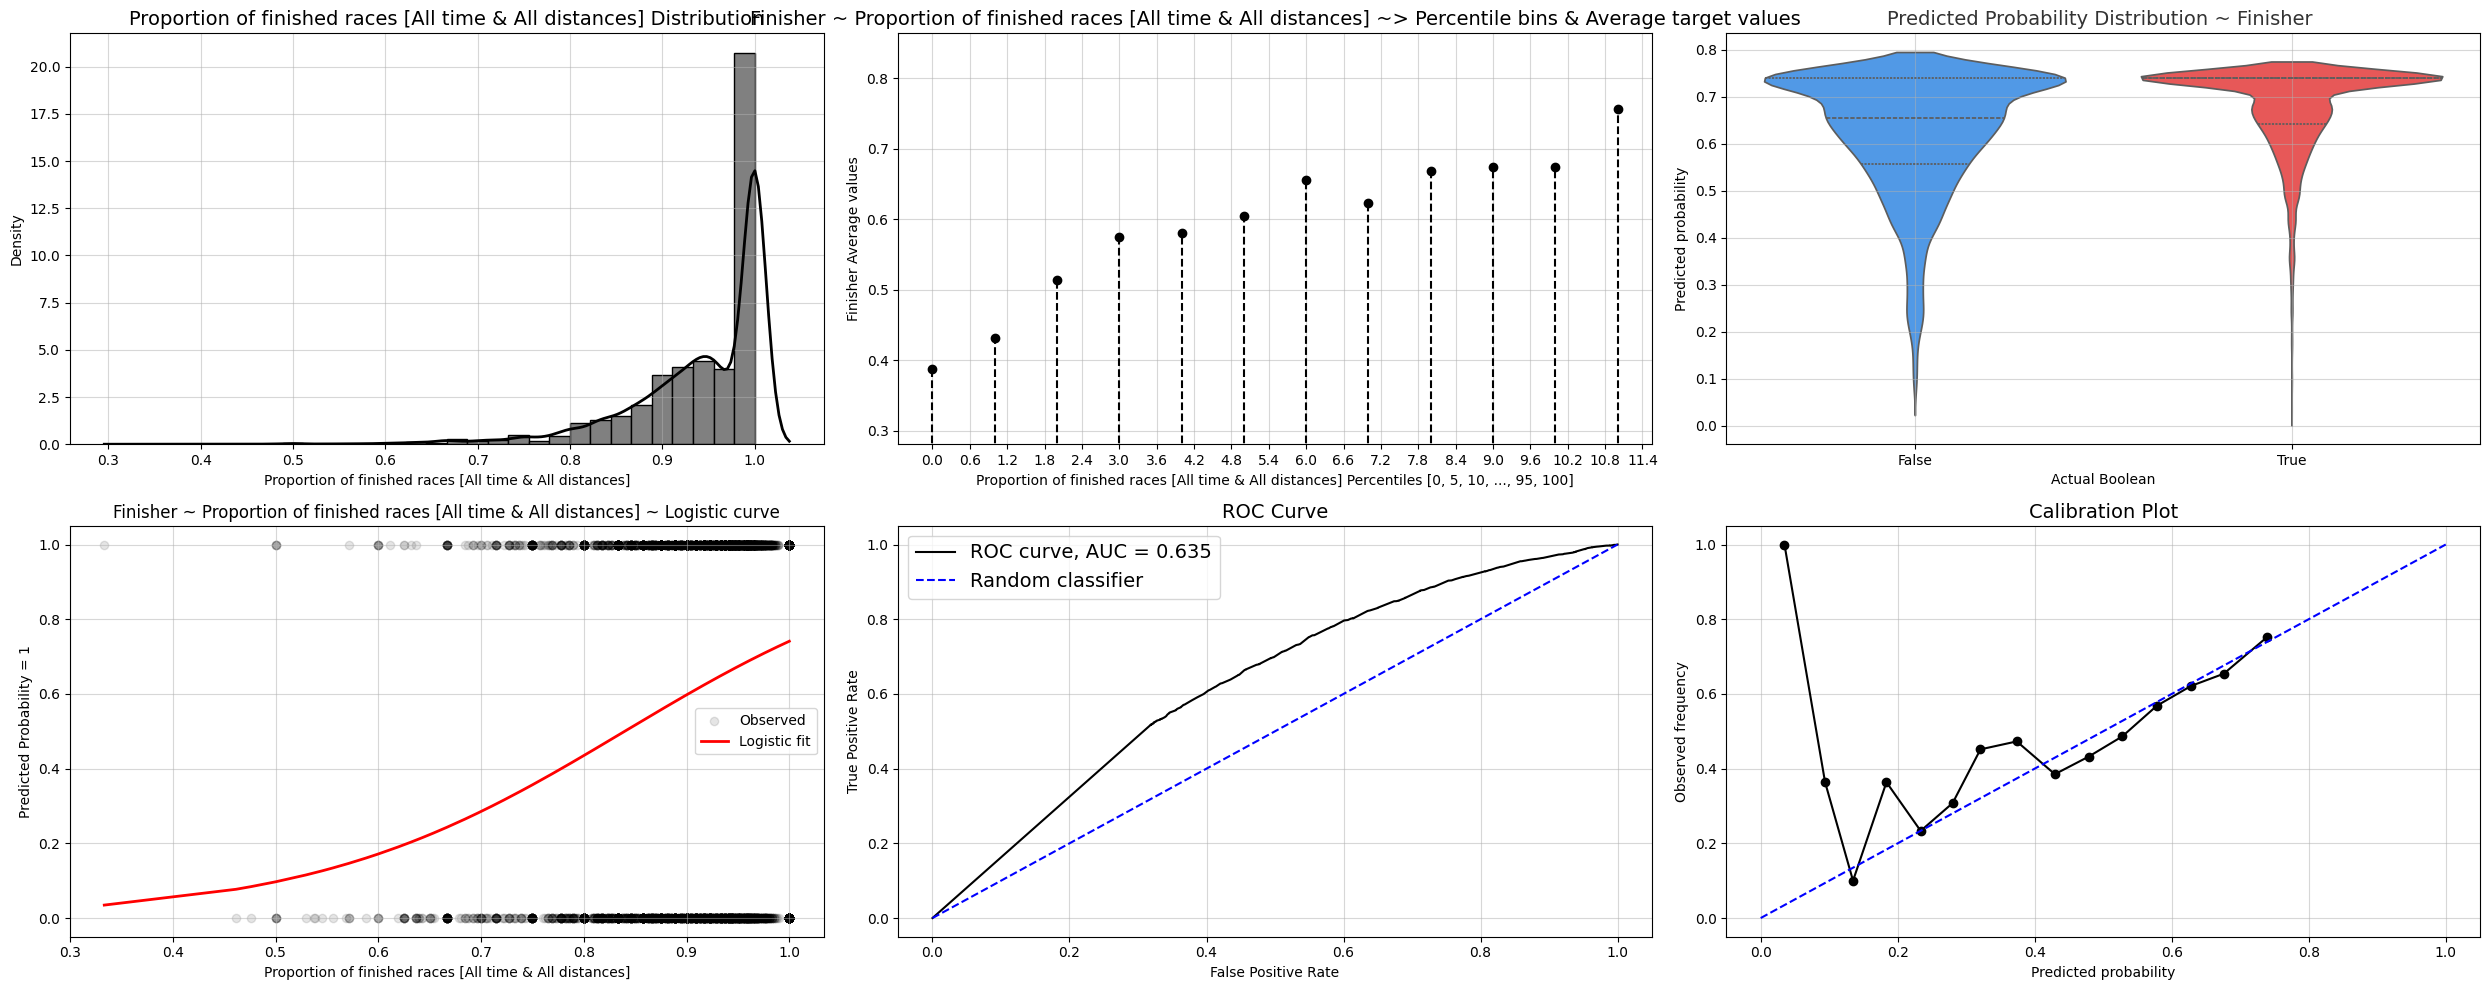

In [17]:
# Proportion of finished races [All time & All distances]

_ = univariate_logit_numeric(
    target = "runner_is_finisher", target_name = "Finisher",
    feature = "alltime_alldist_finish_prop", feature_name = "Proportion of finished races [All time & All distances]",
    data = race_results_runner_statistics_train,
    alpha = 0.1,
    print_metrics = True,
    show_plot = True
    )

---
### Race Finish Success - Full model

In [18]:
# Import help functions
from helpers.logistic_regression_help_functions import full_logit_model_analysis

Model

-----------------------------------------------------
Finisher ~
Proportion of finished races [All time & All distances] + 
Proportion of finished races [All time & 100 miles] + 
Proportion of finished races [Last 2 years & 100 miles] + 
Age + 
Gender Male 
~> Logistic regression
-----------------------------------------------------


Model metrics on Train data:
------------------------------------
Pseudo R2 ~> 0.0686
Log-Likelihood ~> -3319.5598
Likelihood Ratio (Chi2) ~> 489.2244
Chi2 test p-value ~> 0.0000
AIC ~> 6651.1196
BIC ~> 6690.9783
AUC ~> 0.6704
mean VIF ~> 31.2345
max VIF ~> 60.4630

Model metrics on Test data:
------------------------------------
Pseudo R2 ~> 0.9467
Log-Likelihood ~> -1092.5199
Likelihood Ratio (Chi2) ~> 38778.8973
Chi2 test p-value ~> 0.0000
AIC ~> 2195.0398
BIC ~> 2222.7243
AUC ~> 0.6677

Features metrics:


,feature,feature name,coef,scaled coef,coef OR,scaled coef OR,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,confidence interval OR,scaled confidence interval OR,VIF
0,alltime_alldist_finish_prop,Proportion of finished races [All time & All d...,5.521823,0.899707,250.090488,2.458883,9.524706e-27,0.515762,0.084037,"[4.5109, 6.5327]","[0.735, 1.0644]","[91.008, 687.2498]","[2.0855, 2.8991]",60.462986
1,alltime_100m_finish_prop,Proportion of finished races [All time & 100 m...,0.488131,0.246474,1.629268,1.279506,2.100148e-02,0.211499,0.106793,"[0.0736, 0.9027]","[0.0372, 0.4558]","[1.0764, 2.4662]","[1.0379, 1.5774]",40.831997
2,last2years_100m_finish_prop,Proportion of finished races [Last 2 years & 1...,0.279585,0.186136,1.322581,1.204586,4.871940e-02,0.141846,0.094435,"[0.0016, 0.5576]","[0.001, 0.3712]","[1.0016, 1.7465]","[1.001, 1.4495]",20.652838
3,runner_age,Age,-0.028050,-0.517130,0.972340,0.596229,7.725589e-16,0.003481,0.064172,"[-0.0349, -0.0212]","[-0.6429, -0.3914]","[0.9657, 0.979]","[0.5258, 0.6761]",25.552344
4,runner_gender_male,Gender Male,0.522147,0.351854,1.685642,1.421701,7.245935e-09,0.090257,0.060820,"[0.3452, 0.699]","[0.2326, 0.4711]","[1.4123, 2.0118]","[1.2619, 1.6017]",8.672212


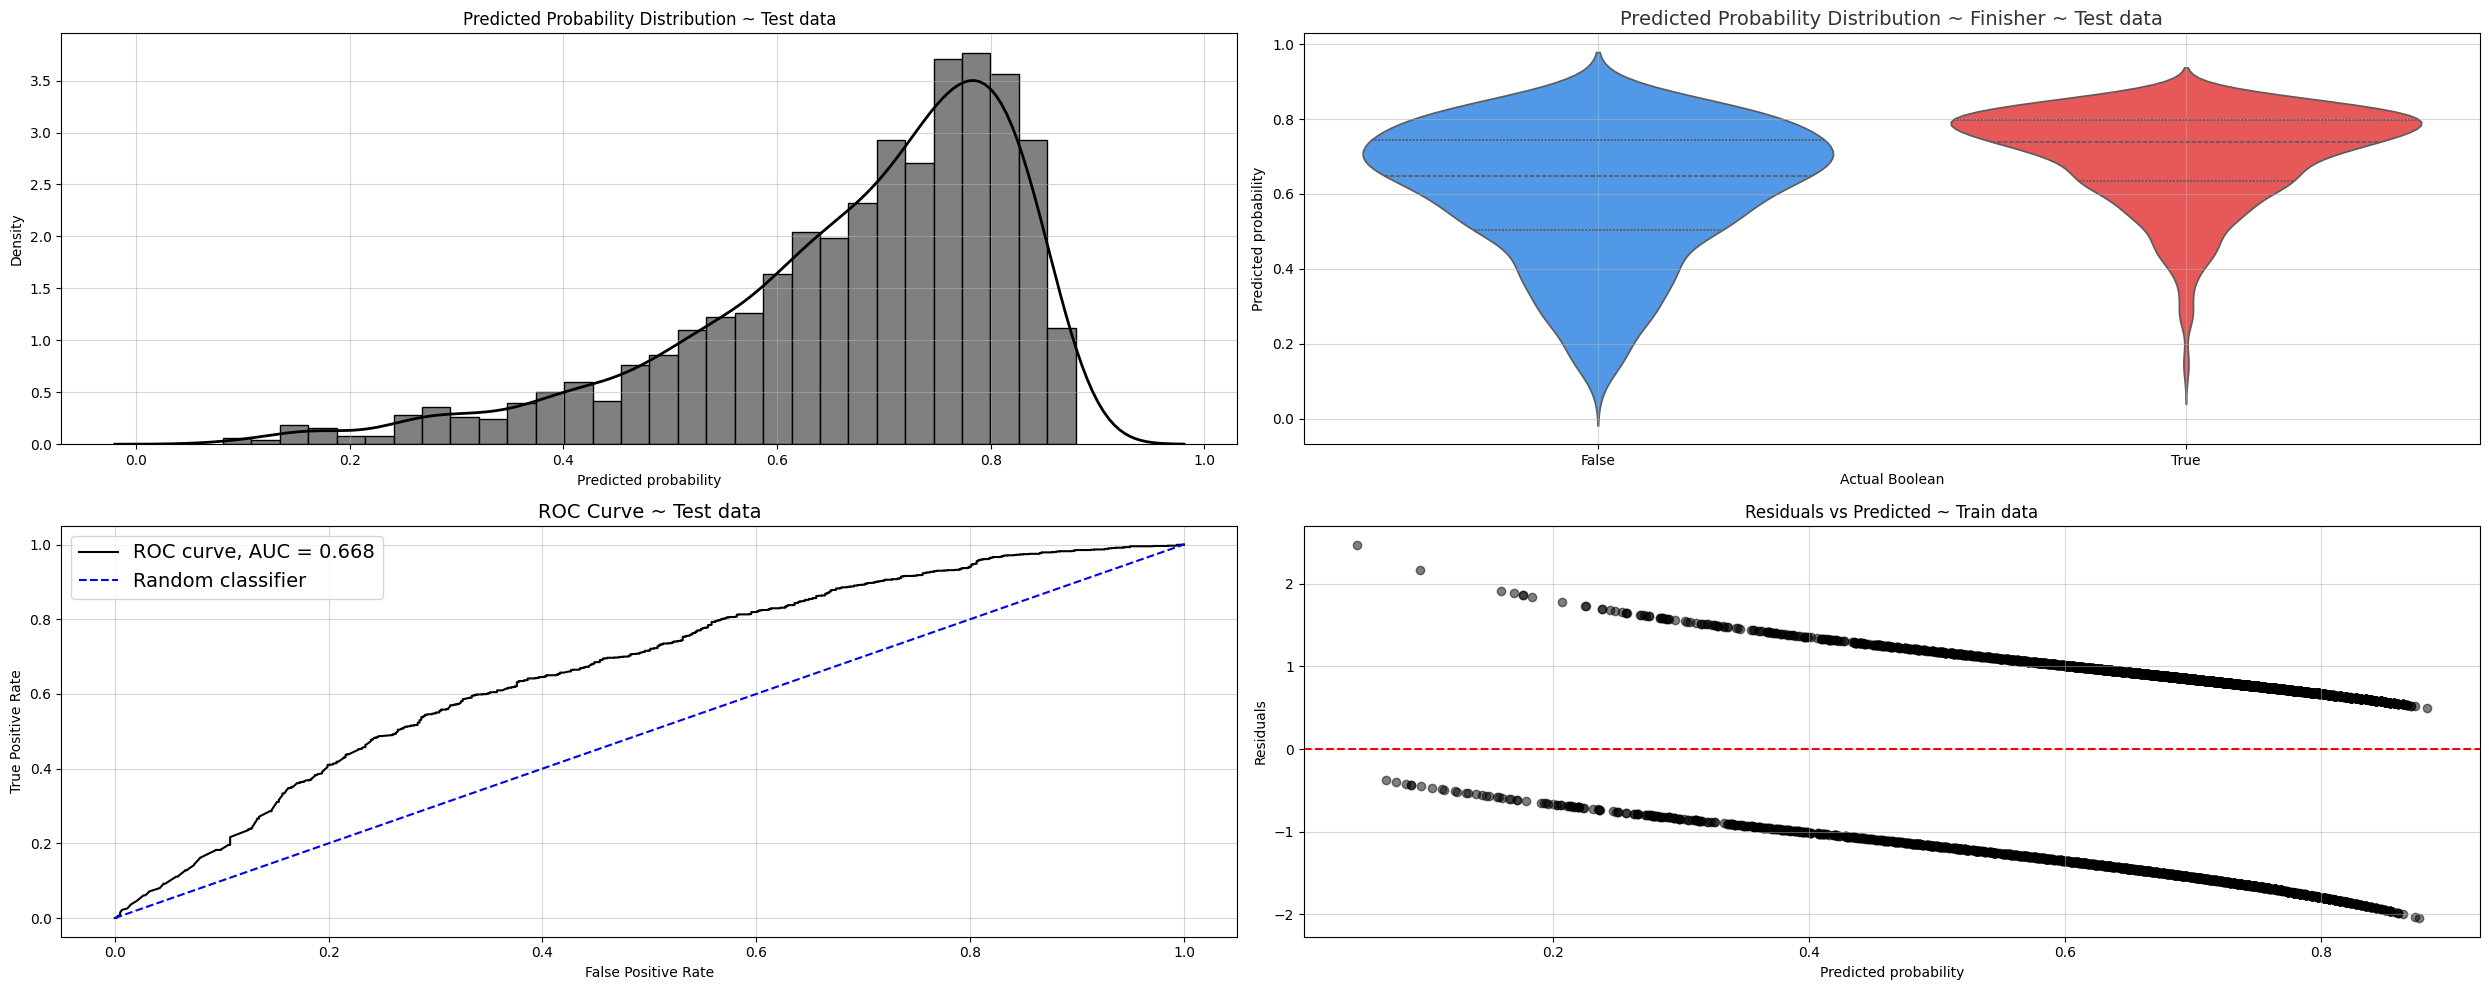

In [19]:
# Model
features_dict = {
    "alltime_alldist_finish_prop": "Proportion of finished races [All time & All distances]",
    "alltime_100m_finish_prop": "Proportion of finished races [All time & 100 miles]",
    "last2years_100m_finish_prop": "Proportion of finished races [Last 2 years & 100 miles]",
    "runner_age": "Age",
    "runner_gender_male": "Gender Male",
    }

_ = full_logit_model_analysis(
    target_dict = {"runner_is_finisher": "Finisher"},
    features_dict = features_dict,
    train_data = race_results_runner_statistics_train, 
    test_data = race_results_runner_statistics_test,
    alpha = 0.3,
    print_metrics = True,
    show_plot = True
    )

---
### Race Finish time ~ Univariate Linear model

In [20]:
# Import help functions
from helpers.linear_regression_help_functions import univariate_ols_numeric, univariate_ols_categorical

Quick run through "feature importances"

In [21]:
# Univariate analysis for all features and save metrics

# Features we want to perform univariate analysis on
features_to_analyse = [
    col for col in race_results_runner_statistics_finished_train.columns if 
        "alltime" in col or 
        "last2years" in col or 
        col in ["runner_pre_race_index", "runner_gender", "runner_age"]
 ]

race_time_features_metrics_list = []
for single_feature in features_to_analyse:

    # Numeric features
    if pd.api.types.is_numeric_dtype(race_results_runner_statistics_finished_train[single_feature]):
        try:
            single_feature_metrics = univariate_ols_numeric(
                target = "runner_race_time_hours", target_name = "Race Time",
                feature = single_feature, feature_name = "Feature",
                data = race_results_runner_statistics_finished_train,
                alpha = 0.1,
                box_cox_transformation = False, 
                print_metrics = False,
                show_plot = False
                )
        except:
            print("Problems for {}".format(single_feature))
    
    # Categorical features
    else:
        try:
            single_feature_metrics = univariate_ols_categorical(
                target = "runner_race_time_hours", target_name = "Race Time",
                feature = single_feature, feature_name = "Feature",
                data = race_results_runner_statistics_finished_train,
                alpha = 0.1,
                box_cox_transformation = False, 
                print_metrics = False,
                show_plot = False
                )
        except:
            print("Problems for {}".format(single_feature))

    # Save feature metrics DataFrame into a list
    race_time_features_metrics_list.append(single_feature_metrics)

# Combine all features metrics into a DataFrame
race_time_features_metrics_df = pd.concat(race_time_features_metrics_list, ignore_index=True)

In [22]:
# Check
race_time_features_metrics_df = race_time_features_metrics_df.sort_values(
    by="scaled coef", 
    key=lambda x: x.abs(), 
    ascending=False
    ).reset_index(drop=True)

race_time_features_metrics_df

,feature,proportion of clipped Box-Cox predicted values,coef,scaled coef,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,R2,R2 adjusted,MAE,RMSE,Pearson correlation coefficient
0,last2years_alldist_avg_race_index,None,-0.05469,-0.854321,0.0,0.000461,0.007197,"[-0.0556, -0.0538]","[-0.8684, -0.8402]",0.729864,0.729812,2.404963,3.063375,0.854321
1,last2years_100m_avg_race_index,None,-0.051525,-0.850593,0.0,0.00053,0.008752,"[-0.0526, -0.0505]","[-0.8678, -0.8334]",0.723509,0.723432,2.506441,3.215201,0.850593
2,last2years_100k_avg_race_index,None,-0.051016,-0.845309,0.0,0.000489,0.008106,"[-0.052, -0.0501]","[-0.8612, -0.8294]",0.714547,0.714481,2.511237,3.199305,0.845309
3,alltime_100m_avg_race_index,None,-0.053515,-0.841543,0.0,0.000508,0.007993,"[-0.0545, -0.0525]","[-0.8572, -0.8259]",0.708195,0.708131,2.518544,3.239718,0.841543
4,alltime_alldist_avg_race_index,None,-0.059134,-0.83711,0.0,0.000531,0.00752,"[-0.0602, -0.0581]","[-0.8519, -0.8224]",0.700754,0.700697,2.526481,3.216474,0.83711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,alltime_sub100k_avg_finisher_rank_prop_trend,None,-0.003168,-0.001424,0.917531,0.030591,0.013748,"[-0.0631, 0.0568]","[-0.0284, 0.0255]",0.000002,-0.000187,4.795634,5.879836,0.001424
143,last2years_sub100k_avg_finisher_rank_prop_gend...,None,-0.001573,-0.001416,0.91799,0.015278,0.013748,"[-0.0315, 0.0284]","[-0.0284, 0.0255]",0.000002,-0.000187,4.795566,5.879836,0.001416
144,last2years_alldist_utmb_index_trend,None,-0.000054,-0.001109,0.935694,0.000675,0.013748,"[-0.0014, 0.0013]","[-0.0281, 0.0258]",0.000001,-0.000188,4.79558,5.879838,0.001109
145,last2years_sub100k_avg_finisher_rank_prop_trend,None,0.001038,0.000919,0.946714,0.015523,0.013748,"[-0.0294, 0.0315]","[-0.026, 0.0279]",0.000001,-0.000188,4.795634,5.879839,0.000919


Feature exploration

-----------------------------------------------------
Race Time ~ Gender ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> [runner_gender_H = None]
coef ~> [runner_gender_H = -0.4971]
scaled coef ~> [runner_gender_H = -0.0254]
p-value ~> [runner_gender_H = 0.0646]
standard error ~> [runner_gender_H = 0.2689]
scaled standard error ~> [runner_gender_H = 0.0137]
confidence interval ~> [runner_gender_H = [-1.0243, 0.0301]]
scaled confidence interval ~> [runner_gender_H = [-0.0523, 0.0015]]
R2 ~> [runner_gender_H = 0.0006]
R2 adjusted ~> [runner_gender_H = 0.0005]
MAE ~> [runner_gender_H = 4.7944]
RMSE ~> [runner_gender_H = 5.8775]
Pearson correlation coefficient ~> [runner_gender_H = 0.0254]


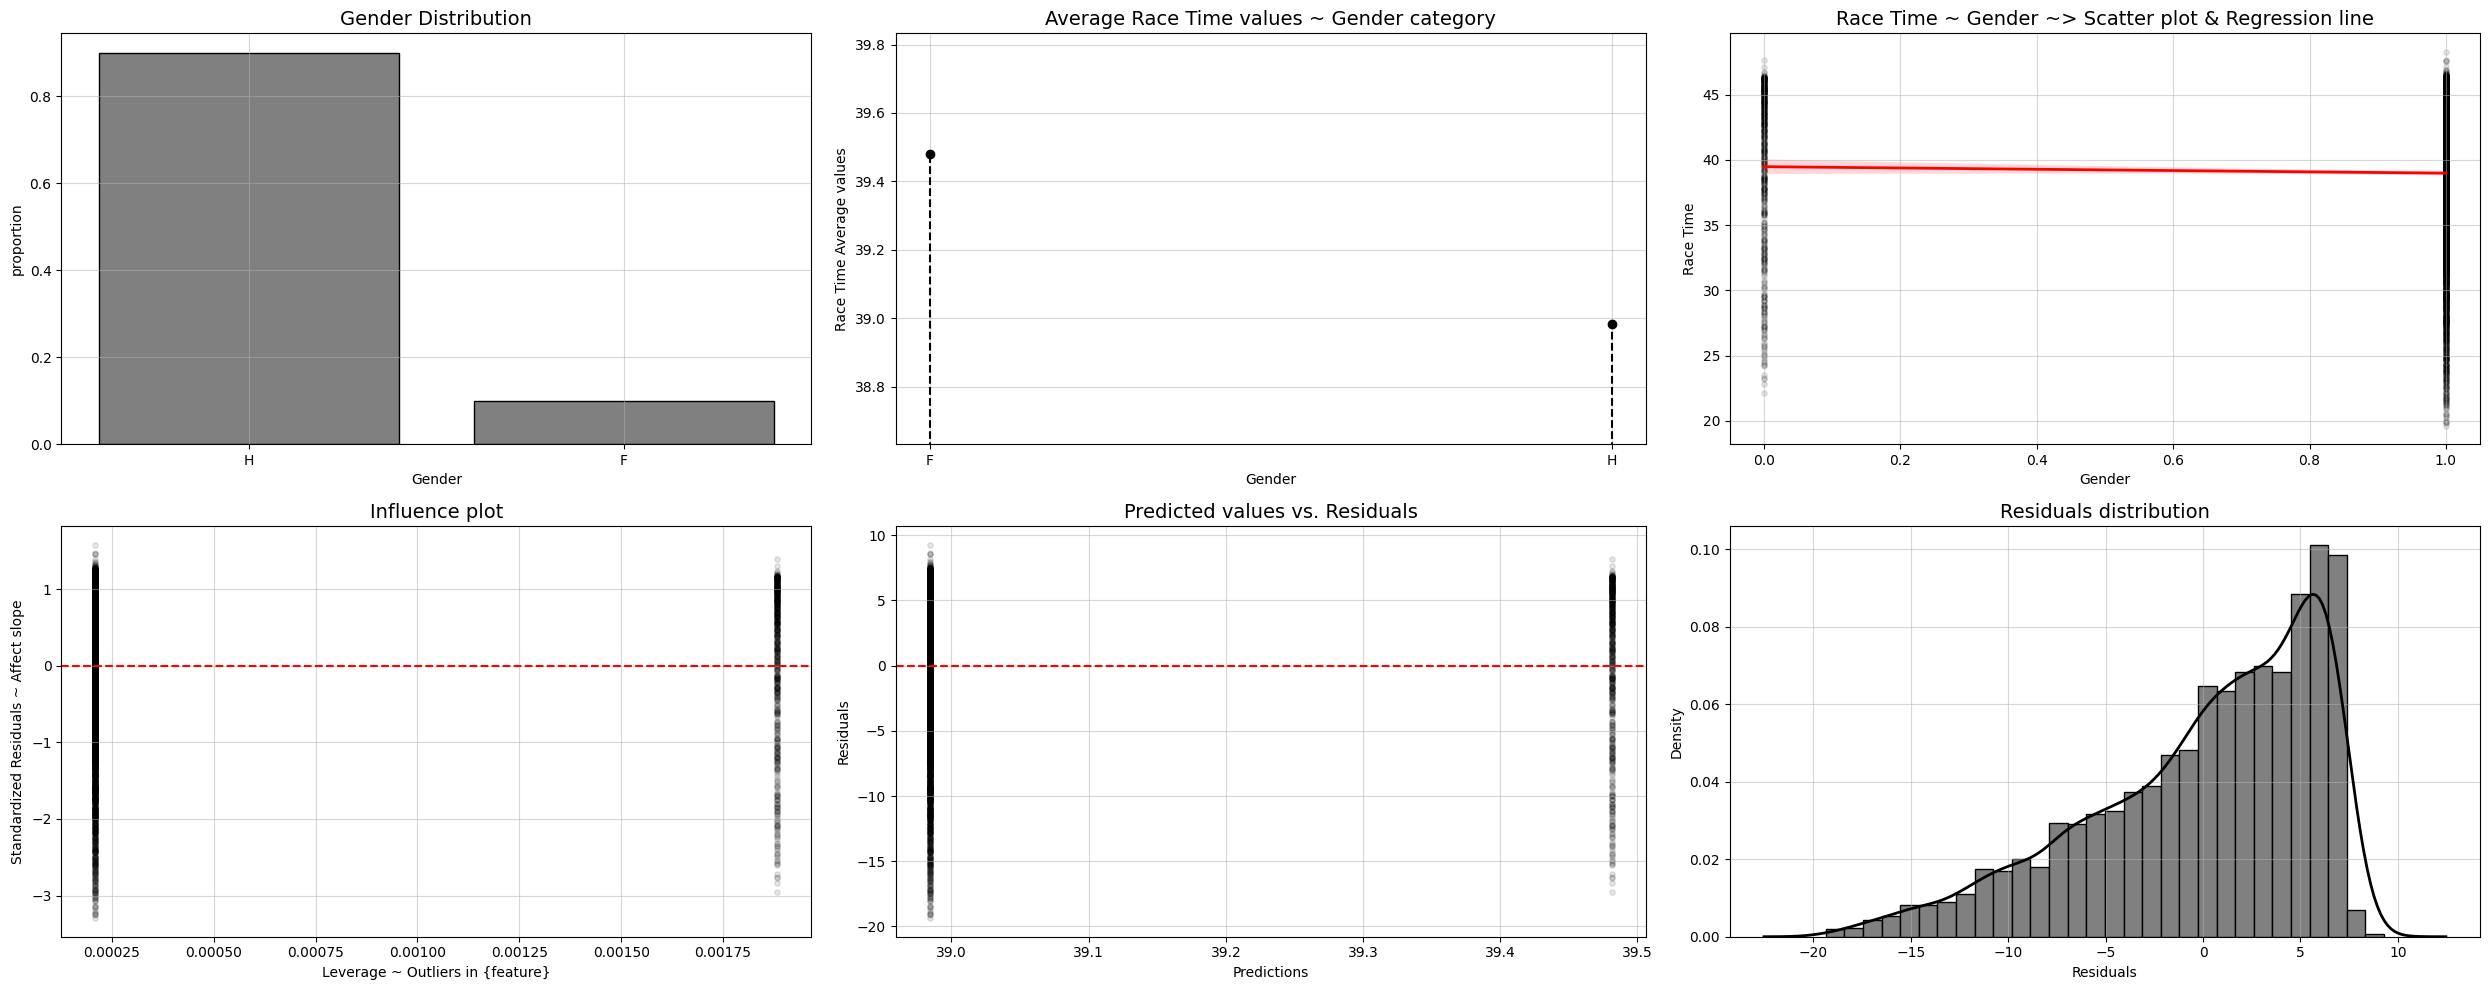

In [23]:
# Gender

_ = univariate_ols_categorical(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "runner_gender", feature_name = "Gender",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Pre-race UTMB index ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> None
coef ~> -0.0510
scaled coef ~> -0.8311
p-value ~> 0.0000
standard error ~> 0.0005
scaled standard error ~> 0.0077
confidence interval ~> ['-0.0520', '-0.0501']
scaled confidence interval ~> ['-0.8462', '-0.8160']
R2 ~> 0.6908
R2 adjusted ~> 0.6907
MAE ~> 2.5999
RMSE ~> 3.2791
Pearson correlation coefficient ~> 0.8311


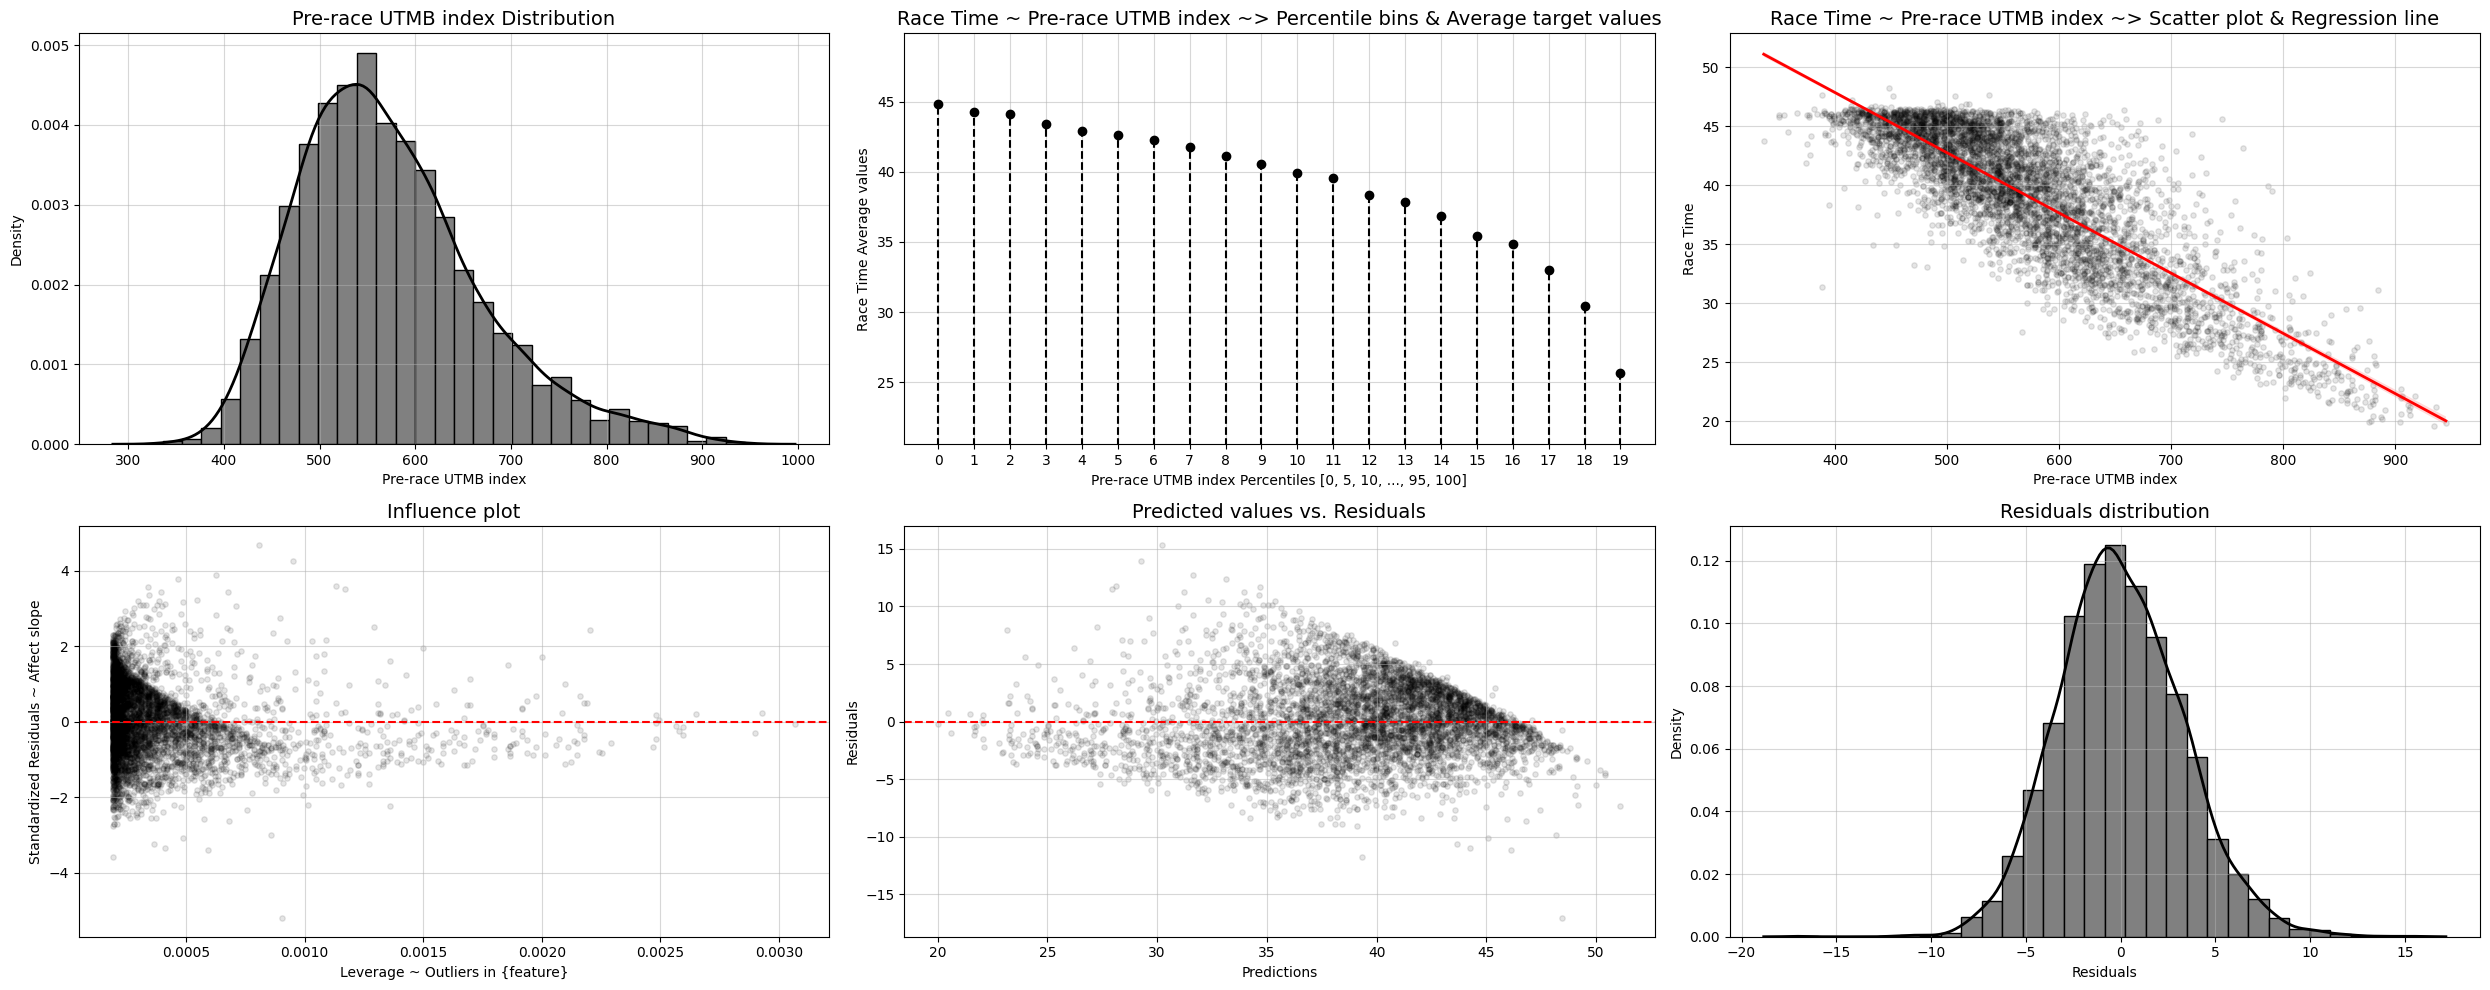

In [24]:
# Pre-race UTMB index

_ = univariate_ols_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "runner_pre_race_index", feature_name = "Pre-race UTMB index",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Last 2 years 100 miles average finisher rank score ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> None
coef ~> -16.7541
scaled coef ~> -0.7474
p-value ~> 0.0000
standard error ~> 0.2478
scaled standard error ~> 0.0111
confidence interval ~> ['-17.2399', '-16.2684']
scaled confidence interval ~> ['-0.7691', '-0.7257']
R2 ~> 0.5586
R2 adjusted ~> 0.5585
MAE ~> 3.1444
RMSE ~> 4.0627
Pearson correlation coefficient ~> 0.7474


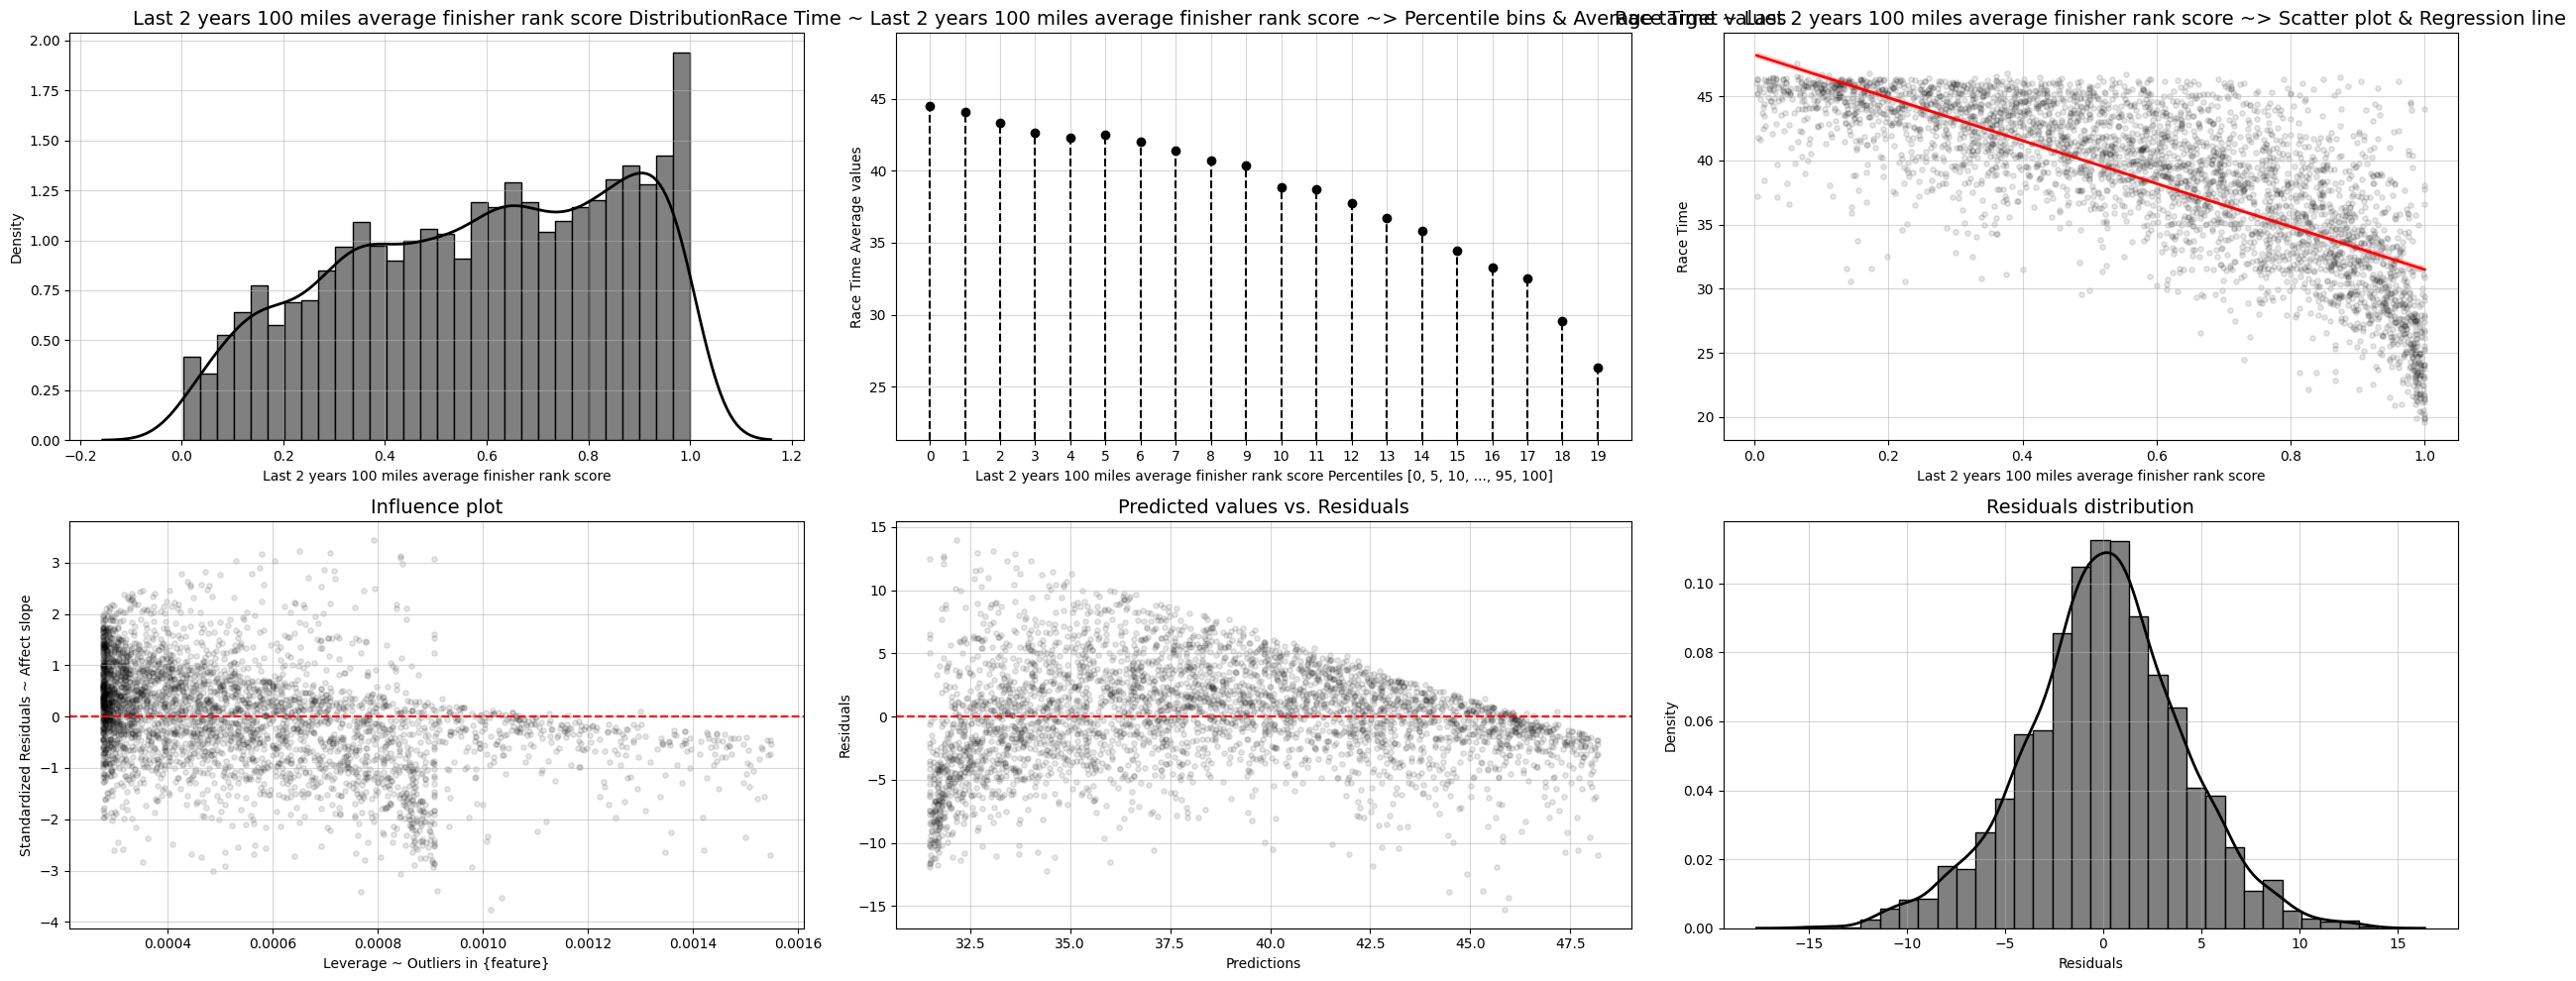

In [25]:
# Last 2 years 100 miles average finisher rank score

_ = univariate_ols_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "last2years_100m_avg_finisher_rank_prop", feature_name = "Last 2 years 100 miles average finisher rank score",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Last 2 years 100 miles average elevation gain adjusted pace ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> None
coef ~> 2.5527
scaled coef ~> 0.6944
p-value ~> 0.0000
standard error ~> 0.0440
scaled standard error ~> 0.0120
confidence interval ~> ['2.4664', '2.6389']
scaled confidence interval ~> ['0.6709', '0.7179']
R2 ~> 0.4822
R2 adjusted ~> 0.4820
MAE ~> 3.5760
RMSE ~> 4.4006
Pearson correlation coefficient ~> 0.6944


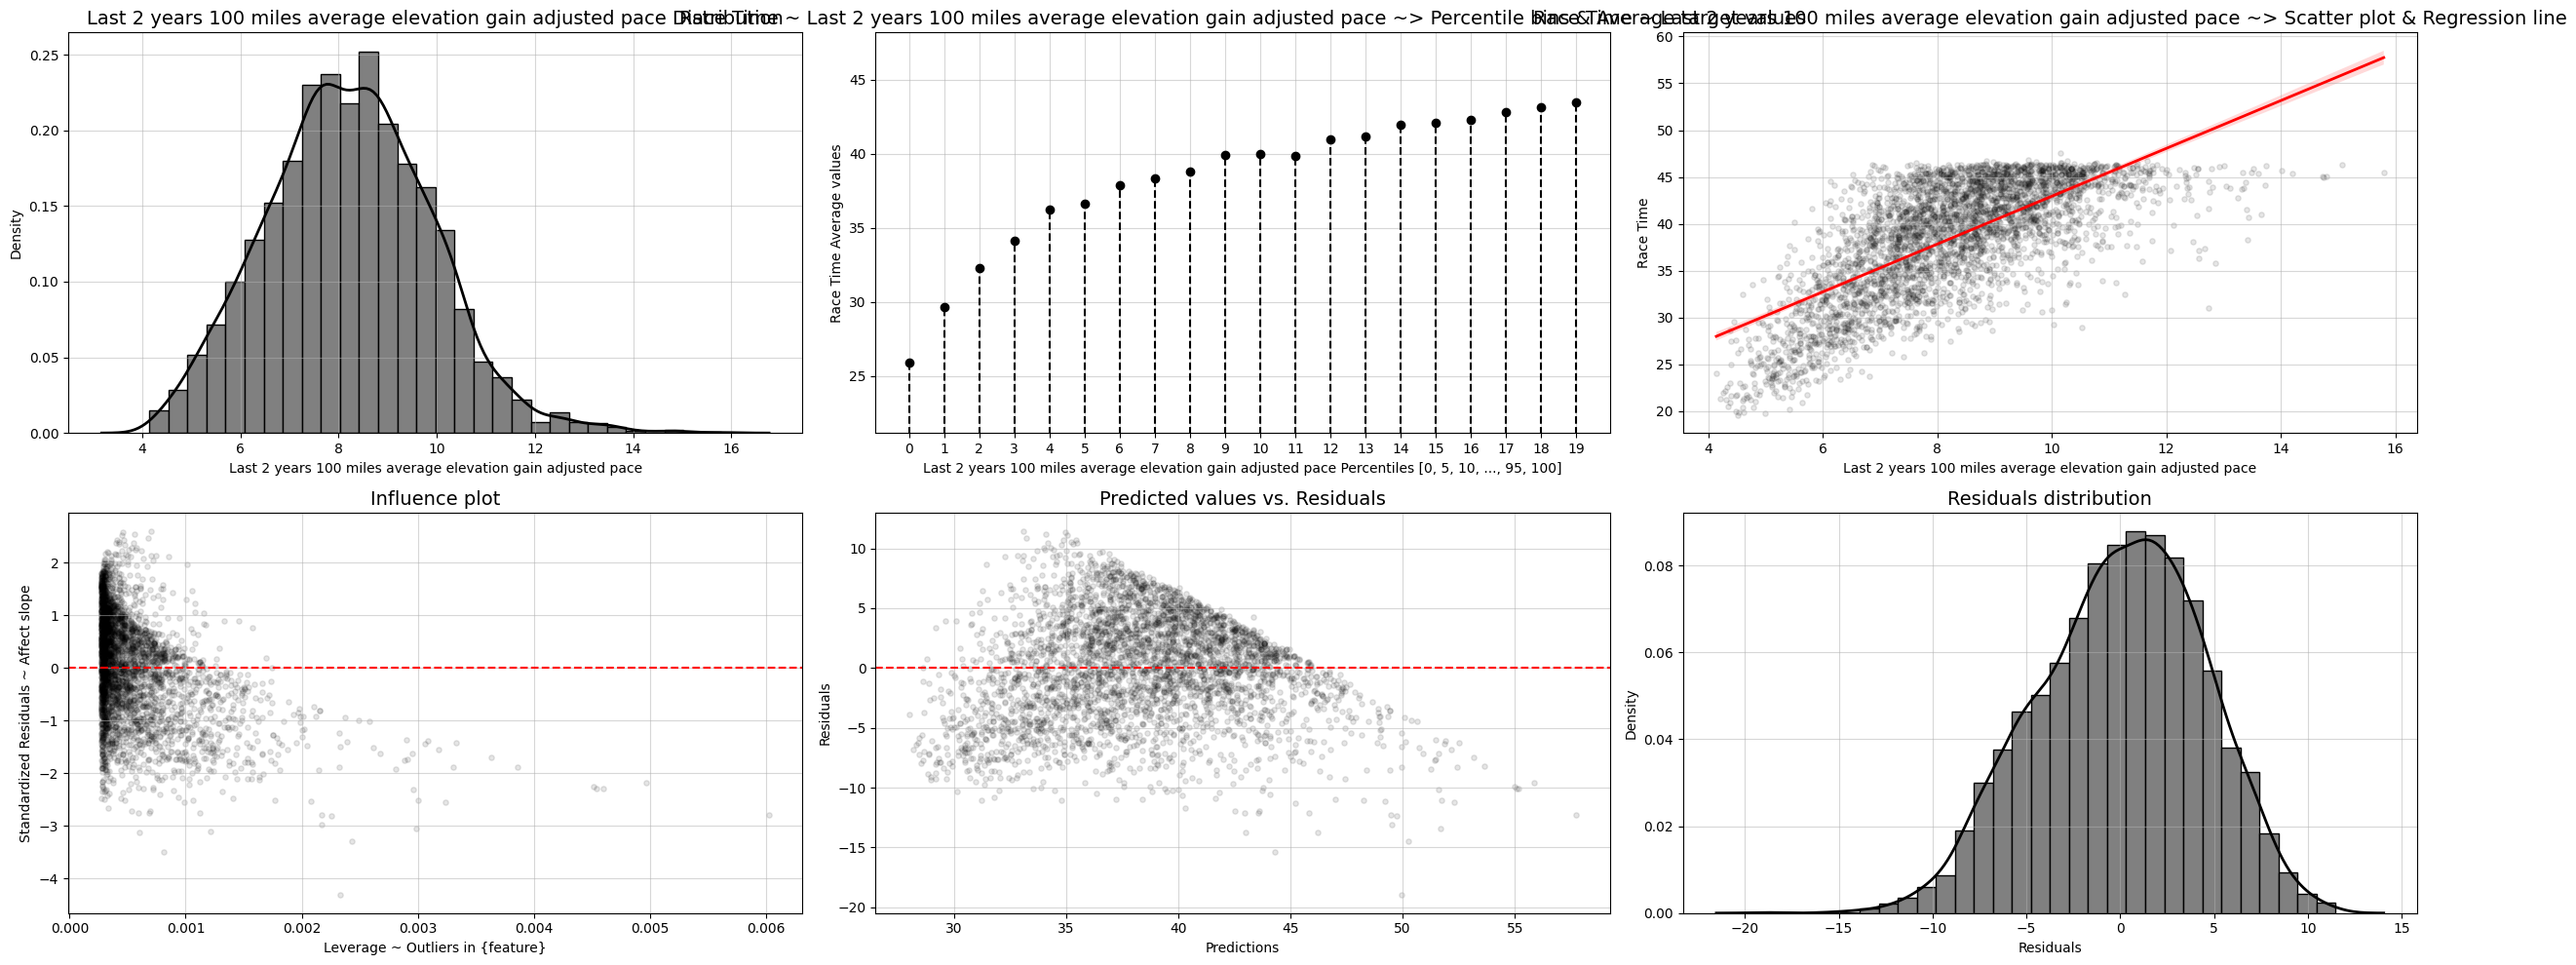

In [26]:
# Last 2 years 100 miles average elevation gain adjusted pace

_ = univariate_ols_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "last2years_100m_avg_elevation_gain_adjusted_pace", feature_name = "Last 2 years 100 miles average elevation gain adjusted pace",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Days from last 100 miles race (max 2 years) ~> Univariate Linear Regression
-----------------------------------------------------

proportion of clipped Box-Cox predicted values ~> None
coef ~> 0.0035
scaled coef ~> 0.0999
p-value ~> 0.0000
standard error ~> 0.0006
scaled standard error ~> 0.0161
confidence interval ~> ['0.0024', '0.0046']
scaled confidence interval ~> ['0.0684', '0.1313']
R2 ~> 0.0100
R2 adjusted ~> 0.0097
MAE ~> 4.9970
RMSE ~> 6.0647
Pearson correlation coefficient ~> 0.0999


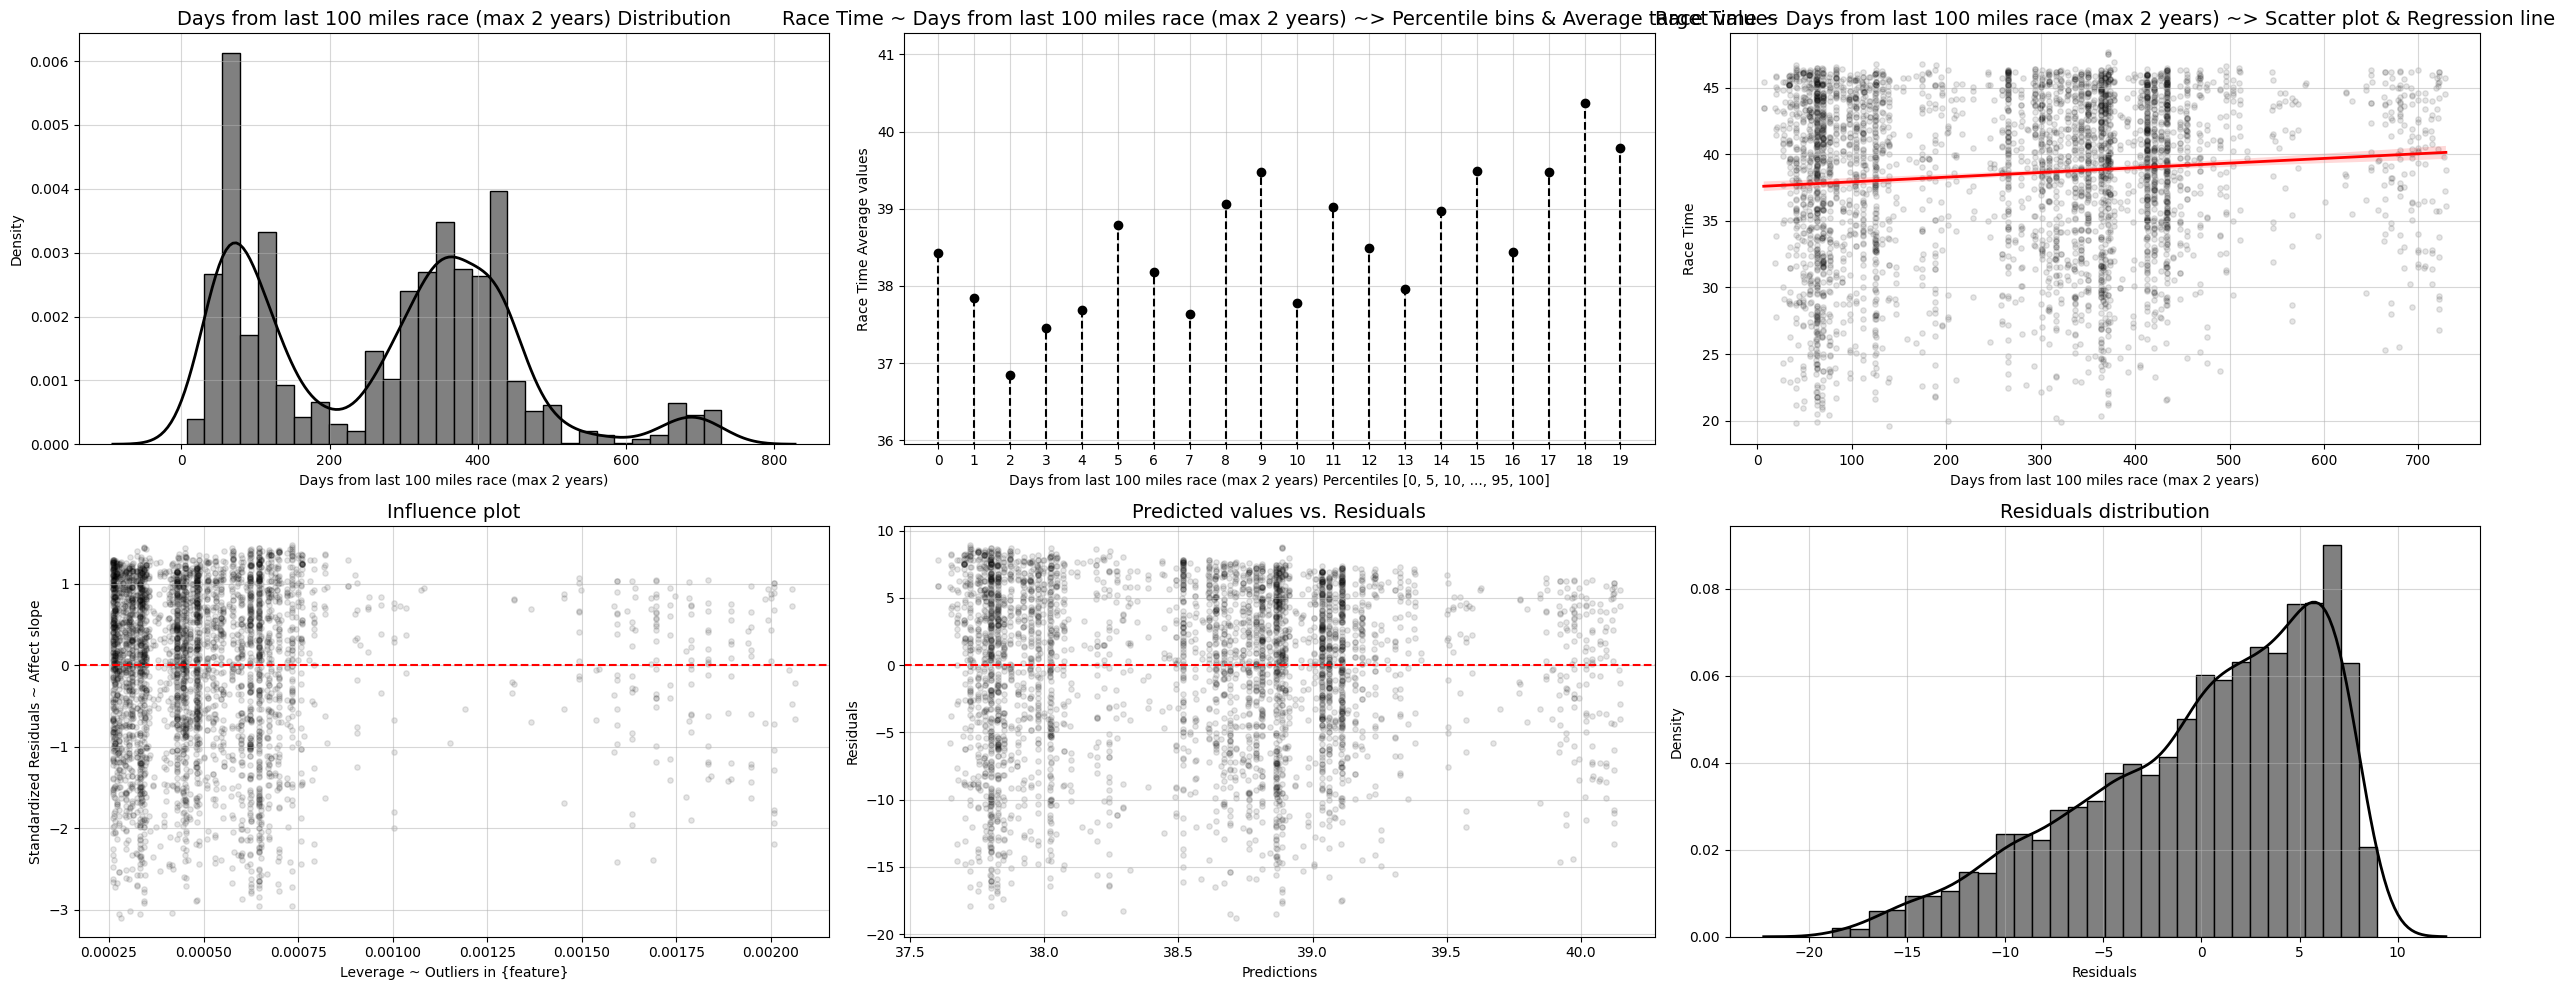

In [27]:
# Days from last 100 miles race (max 2 years)

_ = univariate_ols_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "last2years_100m_days_from_last_race", feature_name = "Days from last 100 miles race (max 2 years)",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = True,
    show_plot = True
    )

---
### Race finish time ~ Full Linear model

In [28]:
# Import help functions
from helpers.linear_regression_help_functions import full_ols_model_analysis

Model

-----------------------------------------------------
Race Time ~
Avg. race UTMB index [Last 2 years & All distances] + 
Avg. race UTMB index [Last 2 years & 100 miles] + 
Avg. race UTMB index [Last 2 years & 100 km] + 
Pre-race UTMB index + 
Age + 
Gender Male 
~> Linear regression
-----------------------------------------------------


Model metrics on Train data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7899
R2 adjusted ~> 0.7894
MAE ~> 2.2484
RMSE ~> 2.8671
Pearson correlation coefficient ~> 0.8887
mean VIF ~> 437.8284
max VIF ~> 1456.4961

Model metrics on Test data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7921
MAE ~> 2.2863
RMSE ~> 2.9394
Pearson correlation coefficient ~> 0.8915

Features metrics:


,feature,feature name,coef,scaled coef,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,VIF
0,last2years_alldist_avg_race_index,Avg. race UTMB index [Last 2 years & All dista...,-0.016506,-0.252162,6.708849e-06,0.003659,0.055897,"[-0.0237, -0.0093]","[-0.3618, -0.1426]",1456.496084
1,last2years_100m_avg_race_index,Avg. race UTMB index [Last 2 years & 100 miles],-0.019111,-0.316305,2.265860e-33,0.001567,0.025940,"[-0.0222, -0.016]","[-0.3672, -0.2654]",254.225848
2,last2years_100k_avg_race_index,Avg. race UTMB index [Last 2 years & 100 km],-0.010631,-0.172597,4.785127e-08,0.001942,0.031530,"[-0.0144, -0.0068]","[-0.2344, -0.1108]",416.272595
3,runner_pre_race_index,Pre-race UTMB index,-0.009902,-0.156538,7.719506e-07,0.001999,0.031602,"[-0.0138, -0.006]","[-0.2185, -0.0946]",475.859823
4,runner_age,Age,0.033116,0.043485,3.593808e-06,0.007133,0.009366,"[0.0191, 0.0471]","[0.0251, 0.0619]",14.524112
5,runner_gender_male,Gender Male,-0.075223,-0.003662,6.743287e-01,0.178992,0.008714,"[-0.4262, 0.2757]","[-0.0207, 0.0134]",9.591990


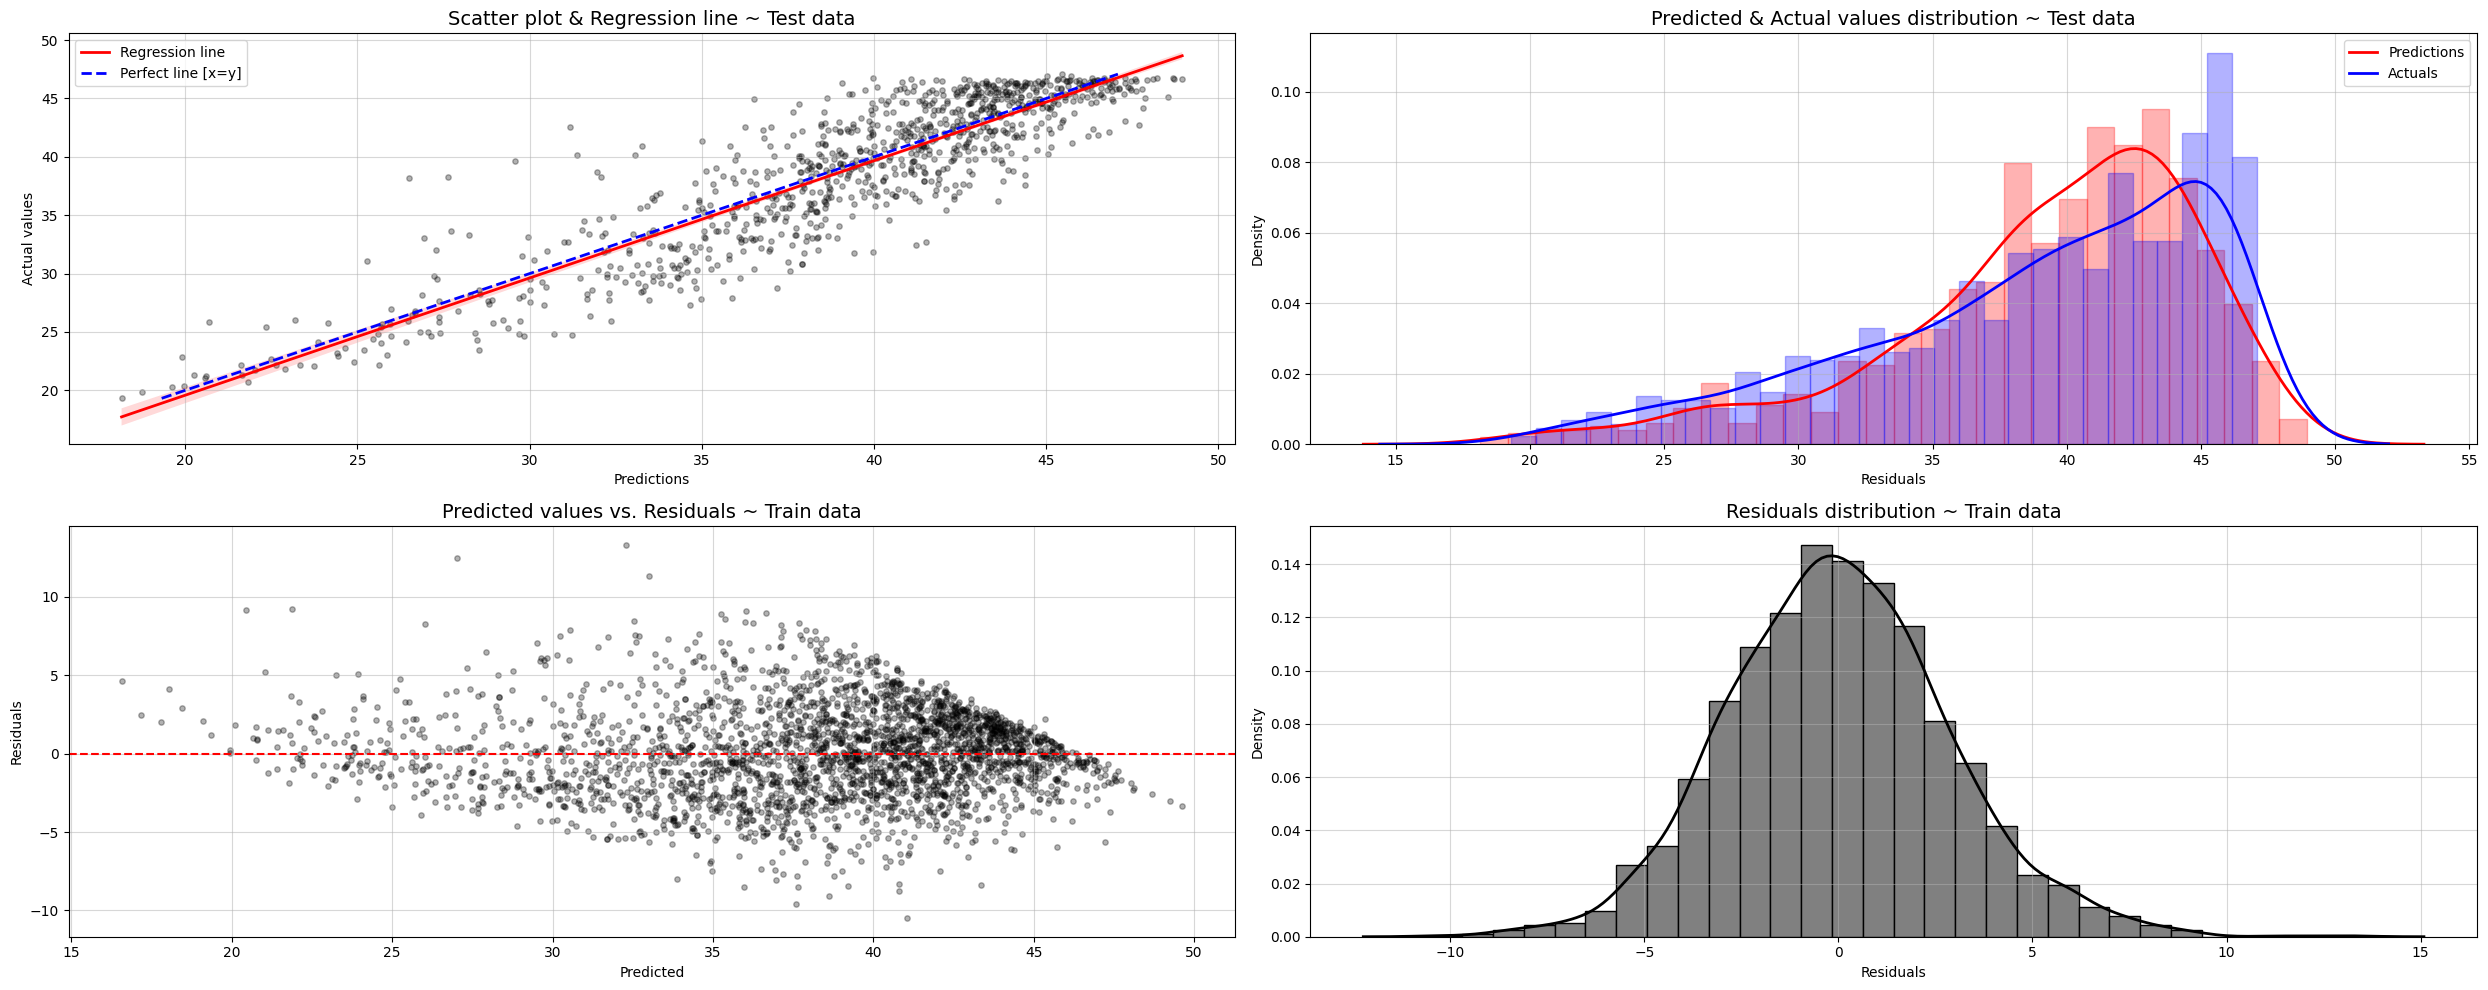

In [29]:
# Model building

features_dict = {
    "last2years_alldist_avg_race_index": "Avg. race UTMB index [Last 2 years & All distances]",
    "last2years_100m_avg_race_index": "Avg. race UTMB index [Last 2 years & 100 miles]",
    "last2years_100k_avg_race_index": "Avg. race UTMB index [Last 2 years & 100 km]",
    "runner_pre_race_index": "Pre-race UTMB index", 
    "runner_age": "Age",
    "runner_gender_male": "Gender Male",
    }

_ = full_ols_model_analysis(
    target_dict = {"runner_race_time_hours": "Race Time"},
    features_dict = features_dict,
    train_data = race_results_runner_statistics_finished_train, 
    test_data = race_results_runner_statistics_finished_test,
    alpha = 0.3,
    box_cox_transformation = False,
    print_metrics = True,
    show_plot = True
    )

Under Race Time ~ Probability Calculation

-----------------------------------------------------
Race Time ~
Pre-race UTMB index 
~> Linear regression
-----------------------------------------------------


Model metrics on Train data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.6908
R2 adjusted ~> 0.6907
MAE ~> 2.5999
RMSE ~> 3.2791
Pearson correlation coefficient ~> 0.8311
mean VIF ~> nan
max VIF ~> nan

Model metrics on Test data:
------------------------------------
proportion of clipped Box-Cox predicted values ~> None
R2 ~> 0.7046
MAE ~> 2.6854
RMSE ~> 3.3597
Pearson correlation coefficient ~> 0.8410

Features metrics:


,feature,feature name,coef,scaled coef,p-value,standard error,scaled standard error,confidence interval,scaled confidence interval,VIF
0,runner_pre_race_index,Pre-race UTMB index,-0.051037,-0.831148,0.0,0.000473,0.007701,"[-0.052, -0.0501]","[-0.8462, -0.816]",NaN


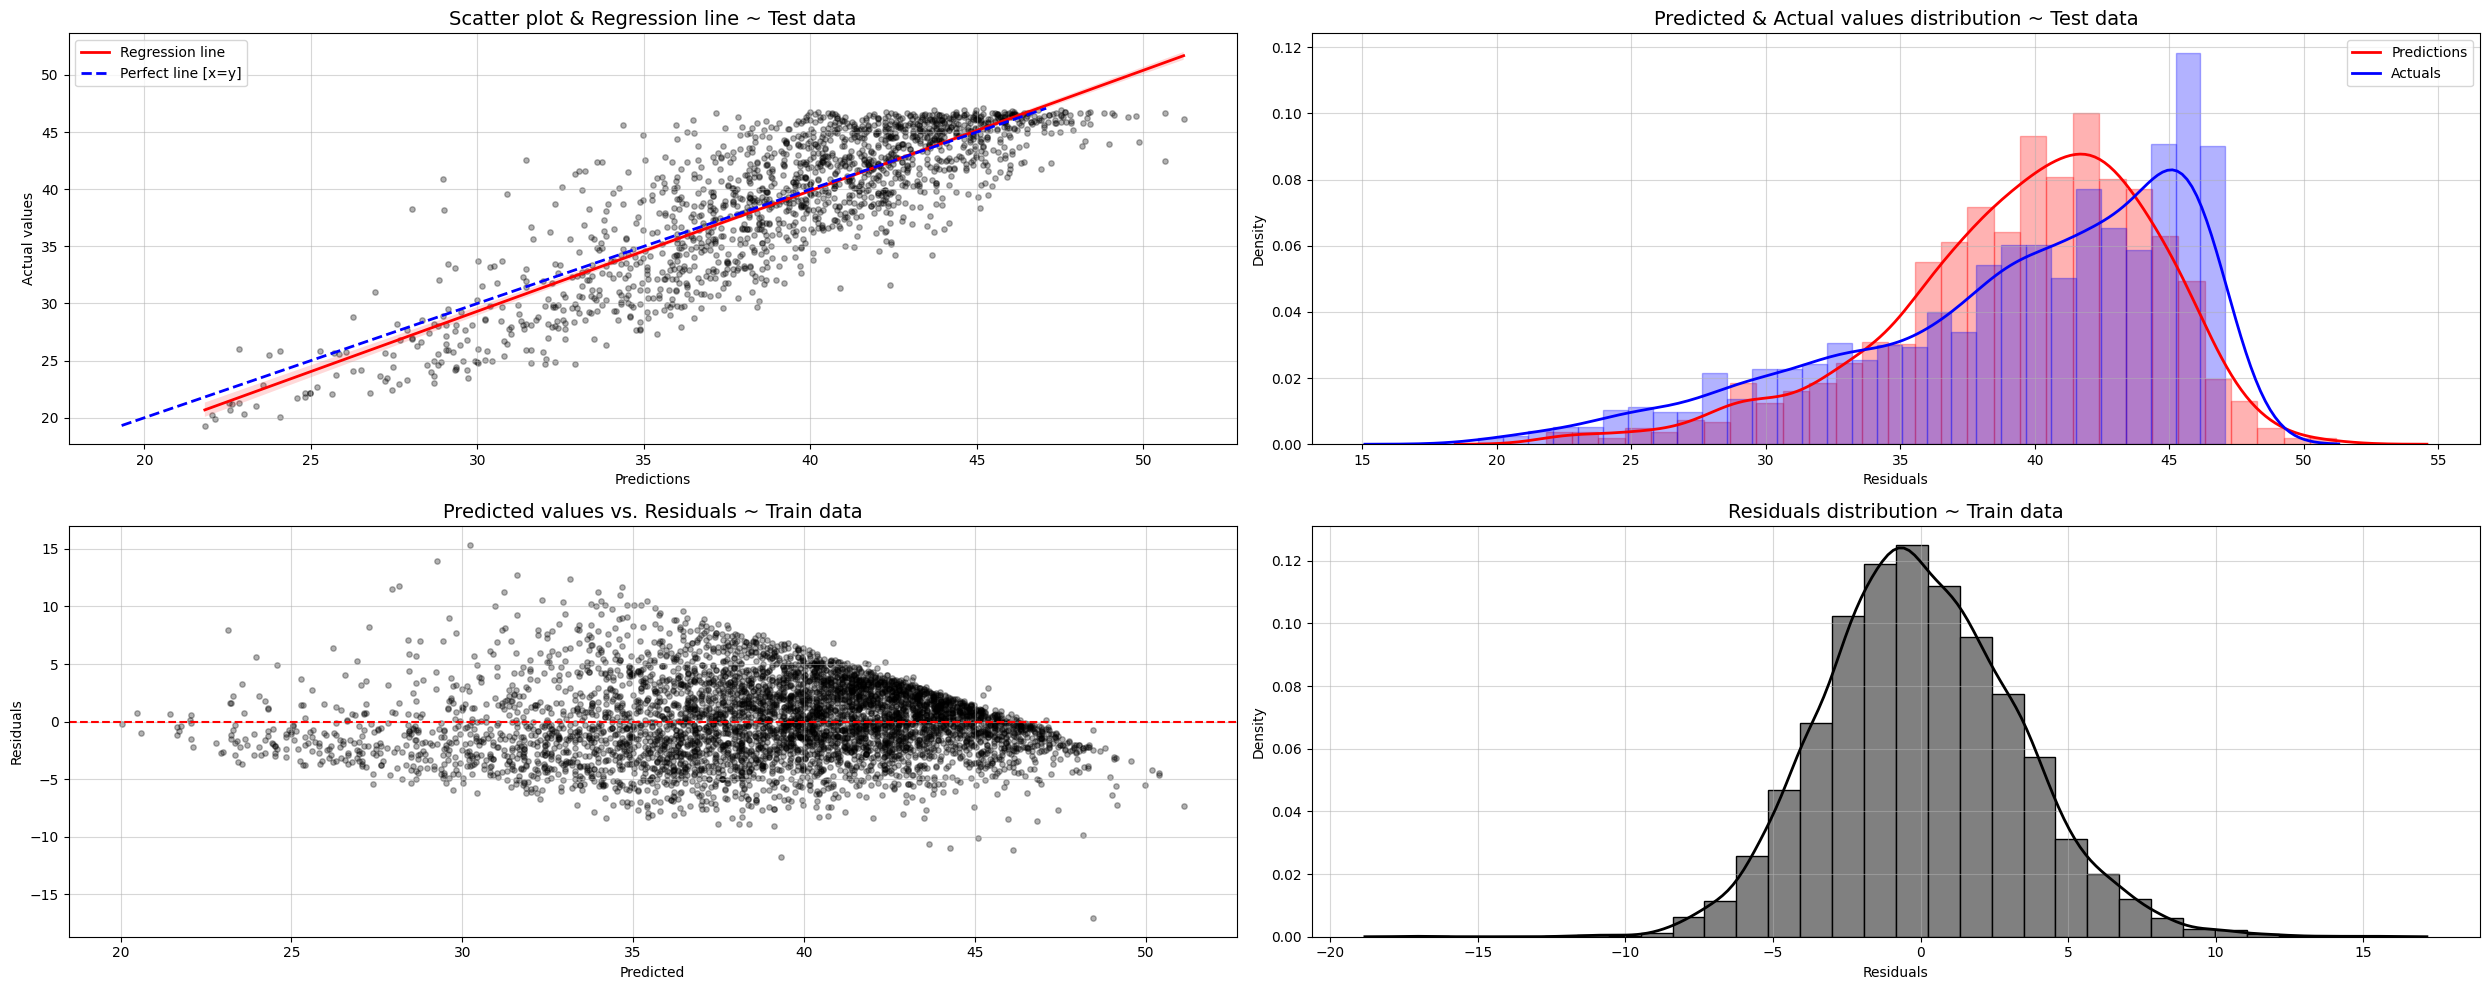

In [30]:
# Pre-race UTMB index Model 

features_dict = {
    "runner_pre_race_index": "Pre-race UTMB index", 
    }

pre_race_utmb_index_model_dict = full_ols_model_analysis(
    target_dict = {"runner_race_time_hours": "Race Time"},
    features_dict = features_dict,
    train_data = race_results_runner_statistics_finished_train, 
    test_data = race_results_runner_statistics_finished_test,
    alpha = 0.3,
    box_cox_transformation = False,
    print_metrics = True,
    show_plot = True
    )

In [31]:
# Probability of running under 27h ~ Solely based on Pre-race UTMB index
from scipy.stats import norm

# Config
target_time_upper = 27
target_prob = 0.95

# Calculate predictions for arraz of pre-race UTMB indices
pre_race_utmb_index_model_fit = pre_race_utmb_index_model_dict["fit"]
utmb_indices = np.arange(400, 951, 1)
X_predict = pd.DataFrame({
    "const": 1, 
    "runner_pre_race_index": utmb_indices,
})

y_pred = pre_race_utmb_index_model_fit.predict(X_predict)
y_pred_summary = pre_race_utmb_index_model_fit.get_prediction(X_predict).summary_frame(alpha=0.05)
resid_std = pre_race_utmb_index_model_fit.resid.std()

# Probability of running under Target time
under_target_time_prob = norm.cdf(target_time_upper, loc=y_pred, scale=resid_std)

# What UTMB index do we need to have, to be 95% sure to run under Target time

beta_const = pre_race_utmb_index_model_fit.params["const"]
beta_utmb_index = pre_race_utmb_index_model_fit.params["runner_pre_race_index"]
z = norm.ppf(target_prob)   
utmb_index_under_target_time_required = (target_time_upper - (beta_const*1) - resid_std*z) / beta_utmb_index

# Full informative DataFrame
full_informative_target_time_df = pd.DataFrame({
    "runner_pre_race_index": utmb_indices,
    "y_pred": y_pred,

    "y_pred_ci_95_lower": y_pred_summary["mean_ci_lower"],
    "y_pred_ci_95_upper": y_pred_summary["mean_ci_upper"],

    "y_pred_pi_95_lower": y_pred_summary["obs_ci_lower"],
    "y_pred_pi_95_upper": y_pred_summary["obs_ci_upper"],

    "prob_under_27": under_target_time_prob
})